# 03d — Shot-Type Classification: Ablation Study

Sequential ablations on ShuttleSet shot-type classification (17 classes).
Each group builds on the best config from the previous group.
Results saved to `results/ablations/{name}.json` — skip to §7 to view without retraining.

| Group | Ablation | Description |
|-------|----------|-------------|
| A | Skeleton representation | L2 vs L3 × dual-player vs single-player |
| B | Temporal window | Fixed T=32 vs variable (hit-frame boundaries) |
| C | Shuttle fusion | None vs graph node vs cross-attention |
| D | Classifier head | Linear vs 1-layer MLP vs 2-layer MLP |


## §1 — Setup & Colab Detection


In [1]:
import os, sys, json, copy, zipfile, time
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    ZIP_PATH     = DRIVE_ROOT / 'baddiev2_colab.zip'
    if not (PROJECT_PATH / 'src').exists():
        print('Extracting project files...')
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(PROJECT_PATH)
    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)

    import src.config as _cfg
    _cfg.MODELS_DIR            = DRIVE_ROOT / 'models'
    _cfg.RESULTS_DIR           = DRIVE_ROOT / 'results'
    _cfg.SS_SKELETONS_GDINO    = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.SS_SHUTTLES           = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_shuttles'
    _cfg.FB_ANNOTATIONS        = (
        DRIVE_ROOT / 'datasets' / 'FineBadminton-dataset' / 'dataset' /
        'transformed_combined_rounds_output_en_evals_translated.json'
    )
    _cfg.SS_CSV_ROOT   = DRIVE_ROOT / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV  = _cfg.SS_CSV_ROOT / 'match.csv'
    _cfg.SS_SPLIT_JSON = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'
    _cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    _cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    print(f'Drive root: {DRIVE_ROOT}')
else:
    sys.path.insert(0, os.path.abspath('..'))
    DRIVE_ROOT = Path('..')
    print('Local run')


Mounted at /content/drive
Extracting project files...
Drive root: /content/drive/MyDrive/Baddiev2


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as _Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, accuracy_score

from src.config import (
    get_config, FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER,
    SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
    SHOT_TYPES, NUM_SHOT_TYPES,
    NUM_NODES, NUM_JOINTS, MODELS_DIR, RESULTS_DIR,
)
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.shuttle_cross_attn import ShuttleCrossAttention

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {device}')

ABLATION_DIR = RESULTS_DIR / 'ablations'
ABLATION_DIR.mkdir(parents=True, exist_ok=True)
print(f'Ablation results: {ABLATION_DIR}')


Device: cuda
Ablation results: /content/drive/MyDrive/Baddiev2/results/ablations


In [3]:
import shutil

local_skel = Path('/content/local_skeletons')
local_shuttle = Path('/content/local_shuttles')

if not local_skel.exists():
    print('Copying skeletons to local SSD...')
    t0 = time.time()
    shutil.copytree(SS_SKELETONS_GDINO, local_skel)
    print(f'Done in {time.time()-t0:.0f}s')

if not local_shuttle.exists():
    print('Copying shuttles to local SSD...')
    t0 = time.time()
    shutil.copytree(SS_SHUTTLES, local_shuttle)
    print(f'Done in {time.time()-t0:.0f}s')

print(f'3 random samples: {time.time()-t0:.2f}s')


Copying skeletons to local SSD...
Done in 35s
Copying shuttles to local SSD...
Done in 87s
3 random samples: 86.55s


## §2 — Shared Functions & Hyperparameters

All ablations use the same:
- Loss: cross-entropy (class-weighted)
- Optimizer: AdamW, lr=1e-3, cosine schedule
- Early stopping on **validation macro-F1** (patience=10) — 2 matches held out from training
- Final evaluation: macro-F1 + accuracy on the **test** set (2 held-out matches, never seen during training or early stopping)


In [4]:
# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Shared hyperparameters ────────────────────────────────────────────────
SHOT_WINDOW   = 32
EPOCHS        = 80
BATCH_SIZE    = 64
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 10
N_CLASSES     = NUM_SHOT_TYPES  # 17

# ── Train / val / test split ─────────────────────────────────────────────
# Val = 2 matches from training set (early stopping); Test = held-out (final eval only)
with open(SS_SPLIT_JSON) as f:
    splits = json.load(f)

VAL_MATCH_NAMES = [
    'NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals',
    'Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals',
]
TRAIN_MATCHES = set(splits['train']) - set(VAL_MATCH_NAMES)
VAL_MATCHES   = set(VAL_MATCH_NAMES)
TEST_MATCHES  = set(splits['held_out'])
print(f'Train: {len(TRAIN_MATCHES)} matches | Val: {len(VAL_MATCHES)} matches | Test: {len(TEST_MATCHES)} matches')


Train: 17 matches | Val: 2 matches | Test: 2 matches


In [5]:
def make_dataset(split_matches, feature_layer='L2', use_hitter=False,
                 use_shuttle=False, shuttle_fusion='graph',
                 variable_window=False):
    """Build a ShuttleSetDataset filtered to the given match set."""
    ds = ShuttleSetDataset(
        skeleton_dir=SS_SKELETONS_GDINO,
        shot_window=SHOT_WINDOW,
        feature_layer=feature_layer,
        load_shot_types=True,
        split=None,
        use_shuttle=use_shuttle,
        shuttle_dir=SS_SHUTTLES,
        use_hitter=use_hitter,
        variable_window=variable_window,
        shuttle_fusion=shuttle_fusion,
    )
    ds.samples = [s for s in ds.samples
                  if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in split_matches]
    n_valid = sum(1 for s in ds.samples if s.get('shot_type_idx') is not None)
    print(f'  {len(ds)} samples ({n_valid} with labels)')
    return ds


class SinglePlayerWrapper(_Dataset):
    """Wraps a ShuttleSetDataset to return only the hitter's 17 joints."""
    def __init__(self, ds):
        self.ds = ds
        self.samples = ds.samples  # expose for class weight computation
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        sample = self.ds[idx]
        x, label = sample[0], sample[1]
        info = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        if hitter == 'bottom':
            x = x[:, :, NUM_JOINTS:NUM_JOINTS*2]
        else:
            x = x[:, :, :NUM_JOINTS]
        return x, label


def collate_fn(batch):
    xs, labels = [], []
    for item in batch:
        xs.append(item[0])
        labels.append(item[1])
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long)


def collate_fn_shuttle(batch):
    xs, labels, shuttles = [], [], []
    for item in batch:
        xs.append(item[0])
        labels.append(item[1])
        if len(item) == 3:
            shuttles.append(item[2])
        else:
            shuttles.append(torch.zeros(2, SHOT_WINDOW))
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long), torch.stack(shuttles)


def compute_class_weights(dataset):
    from collections import Counter
    labels = [s.get('shot_type_idx') for s in dataset.samples
              if s.get('shot_type_idx') is not None]
    counts = Counter(labels)
    total = sum(counts.values())
    weights = torch.ones(N_CLASSES, dtype=torch.float32)
    for cls_id, cnt in counts.items():
        weights[cls_id] = total / (len(counts) * cnt)
    return weights


In [6]:
def build_encoder(in_channels, num_nodes, use_inter_player=True, single_player=False):
    """Build ST-GCN encoder + adjacency for the given config."""
    graph = GraphBuilder(
        use_inter_player=use_inter_player,
        single_player=single_player,
    )
    adj = graph.build_adjacency().to(device)
    n_nodes = NUM_JOINTS if single_player else NUM_NODES
    encoder = STGCN(
        in_channels=in_channels,
        num_nodes=n_nodes,
        adjacency=adj,
        num_layers=9,
        base_channels=64,
        embedding_dim=256,
        temporal_kernel=9,
        dropout=0.3,
    ).to(device)
    return encoder


def evaluate(encoder, head, ds, cross_attn_module=None):
    """Run batched evaluation, return (macro_f1, accuracy, y_true, y_pred)."""
    use_cross_attn = cross_attn_module is not None
    cfn = collate_fn_shuttle if use_cross_attn else collate_fn

    loader = DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=0, pin_memory=True, collate_fn=cfn,
    )

    encoder.eval(); head.eval()
    if use_cross_attn:
        cross_attn_module.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if use_cross_attn:
                xb, yb, shuttle_b = batch
                shuttle_b = shuttle_b.to(device)
            else:
                xb, yb = batch

            valid = yb >= 0
            if not valid.any():
                continue

            xb_v = xb[valid].to(device)
            emb = encoder(xb_v)

            if use_cross_attn:
                emb = cross_attn_module(emb, shuttle_b[valid].to(device))

            logits = head(emb)
            all_preds.append(logits.cpu())
            all_labels.append(yb[valid])

    if not all_preds:
        return 0.0, 0.0, np.array([]), np.array([]), {}

    all_logits = torch.cat(all_preds)          # (N, C)
    y_true = torch.cat(all_labels).numpy()
    y_pred = all_logits.argmax(dim=1).numpy()
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    # Top-k accuracy
    topk_metrics = {}
    y_true_t = torch.tensor(y_true, dtype=torch.long)
    for k in [3, 5]:
        if all_logits.shape[1] >= k:
            topk_preds = all_logits.topk(k, dim=1).indices
            correct = topk_preds.eq(y_true_t.unsqueeze(1)).any(dim=1)
            topk_metrics[f'top{k}_acc'] = correct.float().mean().item()

    return macro_f1, accuracy, y_true, y_pred, topk_metrics


def train_and_evaluate(name, train_ds, val_ds, test_ds, encoder, head,
                       cross_attn_module=None, epochs=EPOCHS, freeze_encoder=False):
    """
    Train encoder + head with CE loss. Early stop on val_ds macro-F1.
    Final evaluation on test_ds (never used for model selection).
    If freeze_encoder=True, only head parameters are trained.
    """
    use_cross_attn = cross_attn_module is not None
    cfn = collate_fn_shuttle if use_cross_attn else collate_fn

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, pin_memory=True, drop_last=True, collate_fn=cfn,
    )

    class_weights = compute_class_weights(train_ds).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    if freeze_encoder:
        for p in encoder.parameters():
            p.requires_grad_(False)
        encoder.eval()
        params = list(head.parameters())
        if use_cross_attn:
            params += list(cross_attn_module.parameters())
    else:
        params = list(encoder.parameters()) + list(head.parameters())
        if use_cross_attn:
            params += list(cross_attn_module.parameters())

    optimizer = optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_f1 = -1.0
    no_improve = 0
    best_state = None
    history = {'train_loss': [], 'val_f1': [], 'val_acc': []}
    t0 = time.time()

    for epoch in range(epochs):
        # ── Train ─────────────────────────────────────────────────────
        if not freeze_encoder:
            encoder.train()
        head.train()
        if use_cross_attn:
            cross_attn_module.train()
        epoch_loss = 0.0
        n_batches = 0

        for batch in tqdm(train_loader, desc=f'[{name}] Epoch {epoch+1}/{epochs}', leave=False):
            if use_cross_attn:
                xb, yb, shuttle_b = batch
                shuttle_b = shuttle_b.to(device)
            else:
                xb, yb = batch

            valid = yb >= 0
            if not valid.any():
                continue

            xb = xb[valid].to(device)
            yb = yb[valid].to(device)

            emb = encoder(xb)

            if use_cross_attn:
                shuttle_b = shuttle_b[valid]
                emb = cross_attn_module(emb, shuttle_b)

            logits = head(emb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            if use_cross_attn:
                torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        scheduler.step()
        avg_loss = epoch_loss / max(n_batches, 1)

        # ── Validate (for early stopping — NOT test set) ─────────────
        val_f1, val_acc, _, _, _ = evaluate(encoder, head, val_ds, cross_attn_module)

        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} | loss: {avg_loss:.4f} | val_f1: {val_f1:.4f}')

        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            no_improve = 0
            state = {
                'encoder': {k: v.cpu().clone() for k, v in encoder.state_dict().items()},
                'head': {k: v.cpu().clone() for k, v in head.state_dict().items()},
            }
            if use_cross_attn:
                state['cross_attn'] = {k: v.cpu().clone()
                                       for k, v in cross_attn_module.state_dict().items()}
            best_state = state
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1} (best val F1: {best_val_f1:.4f})')
                break

    train_time = time.time() - t0

    # ── Restore best checkpoint ───────────────────────────────────────
    if best_state:
        encoder.load_state_dict(best_state['encoder'])
        head.load_state_dict(best_state['head'])
        if use_cross_attn and 'cross_attn' in best_state:
            cross_attn_module.load_state_dict(best_state['cross_attn'])

    # ── Final evaluation on TEST set (unseen during training + early stopping)
    macro_f1, accuracy, y_true, y_pred, topk = evaluate(encoder, head, test_ds, cross_attn_module)
    stopped_epoch = len(history['train_loss'])

    present_labels = sorted(set(y_true) | set(y_pred))
    label_names = [SHOT_TYPES[i] if i < len(SHOT_TYPES)
                   else f'type_{i}' for i in present_labels]

    print(f'\n  === {name} ====')
    print(f'  Test Accuracy:  {accuracy:.4f}')
    print(f'  Test Macro-F1:  {macro_f1:.4f}')
    top3 = topk.get('top3_acc', 0)
    top5 = topk.get('top5_acc', 0)
    print(f'  Top-3 Accuracy: {top3:.4f}')
    print(f'  Top-5 Accuracy: {top5:.4f}')
    print(f'  Best Val F1:    {best_val_f1:.4f}')
    print(f'  Epochs:         {stopped_epoch}')
    print(f'  Time:           {train_time:.0f}s')
    print(classification_report(
        y_true, y_pred, labels=present_labels,
        target_names=label_names, zero_division=0,
    ))

    report = classification_report(
        y_true, y_pred, labels=present_labels,
        target_names=label_names, zero_division=0, output_dict=True,
    )

    result = {
        'name': name,
        'accuracy': round(accuracy, 4),
        'macro_f1': round(macro_f1, 4),
        'top3_acc': round(topk.get('top3_acc', 0), 4),
        'top5_acc': round(topk.get('top5_acc', 0), 4),
        'best_val_f1': round(best_val_f1, 4),
        'stopped_epoch': stopped_epoch,
        'train_time_s': round(train_time, 1),
        'n_train': int(len(train_ds)),
        'n_val': int(len(val_ds)),
        'n_test': int(len(test_ds)),
        'n_test_labeled': int(len(y_true)),
        'history': history,
        'per_class': report,
    }
    save_path = ABLATION_DIR / f'{name}.json'
    with open(save_path, 'w') as f:
        json.dump(result, f, indent=2)
    print(f'  Saved: {save_path}')

    ckpt_path = MODELS_DIR / f'ablation_{name}.pt'
    ckpt = {
        'encoder_state_dict': encoder.state_dict(),
        'head_state_dict': head.state_dict(),
        'name': name,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
    }
    if use_cross_attn:
        ckpt['cross_attn_state_dict'] = cross_attn_module.state_dict()
    torch.save(ckpt, ckpt_path)
    print(f'  Checkpoint: {ckpt_path}')

    return result



## §3 — Group A: Skeleton Representation

Vary **feature layer** (L2 vs L3), **player count** (dual 34-node vs single 17-node),
and **hitter identity** (binary channel indicating which player hit the shuttle).
No shuttle. Fixed T=32 window.

| # | Config | Features | Nodes | What it tests |
|---|--------|----------|-------|---------------|
| A1 | Dual L2 | 9-dim (xy + vel + court) | 34 | Baseline |
| A2 | Dual L3 | 12-dim (+ joint angles) | 34 | Do biomechanical features help? |
| A3 | Single L2 | 9-dim | 17 | Does opponent skeleton help? |
| A4 | Single L3 | 12-dim | 17 | Interaction: feature layer × player count |
| A5 | Dual L2 + hitter | 10-dim | 34 | Does hitter identity help? |
| A6 | Dual L3 + hitter | 13-dim | 34 | Hitter + biomechanical features |



In [7]:
# ── A1: Dual-player, L2 (baseline) ────────────────────────────────────────
print('A1: Dual-player, L2 features (9-dim, 34 nodes)')
train_A1 = make_dataset(TRAIN_MATCHES, feature_layer='L2')
val_A1   = make_dataset(VAL_MATCHES, feature_layer='L2')
test_A1  = make_dataset(TEST_MATCHES, feature_layer='L2')

encoder_A1 = build_encoder(in_channels=FEATURE_DIMS['L2'], num_nodes=NUM_NODES)
head_A1 = nn.Linear(256, N_CLASSES).to(device)
print(f'Parameters: {sum(p.numel() for p in encoder_A1.parameters()) + sum(p.numel() for p in head_A1.parameters()):,}')

result_A1 = train_and_evaluate('A1_dual_L2', train_A1, val_A1, test_A1, encoder_A1, head_A1)


A1: Dual-player, L2 features (9-dim, 34 nodes)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)
Parameters: 3,087,568


  Epoch  10/80 | loss: 0.7623 | val_f1: 0.4850


  Epoch  20/80 | loss: 0.3891 | val_f1: 0.5296


  Epoch  30/80 | loss: 0.1679 | val_f1: 0.5178


  Epoch  40/80 | loss: 0.0685 | val_f1: 0.5195


  Epoch  50/80 | loss: 0.0272 | val_f1: 0.5345


  Epoch  60/80 | loss: 0.0142 | val_f1: 0.5379


  Epoch  70/80 | loss: 0.0089 | val_f1: 0.5353


  Early stopping at epoch 72 (best val F1: 0.5442)

  === A1_dual_L2 ====
  Test Accuracy:  0.6060
  Test Macro-F1:  0.5461
  Top-3 Accuracy: 0.8611
  Top-5 Accuracy: 0.9121
  Best Val F1:    0.5442
  Epochs:         72
  Time:           1093s
                precision    recall  f1-score   support

   short_serve       0.97      0.98      0.97       133
    long_serve       0.60      0.75      0.67         4
         smash       0.52      0.46      0.49       107
     tap_smash       0.34      0.48      0.40        75
     push_rush       0.36      0.32      0.34        31
         clear       0.93      0.88      0.90       129
    slice_drop       0.38      0.66      0.48        61
      net_drop       0.85      0.78      0.81       296
    transition       0.76      0.42      0.54        88
         drive       0.65      0.19      0.29       106
         block       0.63      0.69      0.66       163
      lob_lift       0.37      0.88      0.52       137
defensive_lift       0.20  

In [8]:
# ── A2: Dual-player, L3 ───────────────────────────────────────────────────
print('A2: Dual-player, L3 features (12-dim, 34 nodes)')
train_A2 = make_dataset(TRAIN_MATCHES, feature_layer='L3')
val_A2   = make_dataset(VAL_MATCHES, feature_layer='L3')
test_A2  = make_dataset(TEST_MATCHES, feature_layer='L3')

encoder_A2 = build_encoder(in_channels=FEATURE_DIMS['L3'], num_nodes=NUM_NODES)
head_A2 = nn.Linear(256, N_CLASSES).to(device)
print(f'Parameters: {sum(p.numel() for p in encoder_A2.parameters()) + sum(p.numel() for p in head_A2.parameters()):,}')

result_A2 = train_and_evaluate('A2_dual_L3', train_A2, val_A2, test_A2, encoder_A2, head_A2)


A2: Dual-player, L3 features (12-dim, 34 nodes)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)
Parameters: 3,088,864


  Epoch  10/80 | loss: 0.7911 | val_f1: 0.4735


  Epoch  20/80 | loss: 0.4127 | val_f1: 0.5301


  Early stopping at epoch 28 (best val F1: 0.5613)

  === A2_dual_L3 ====
  Test Accuracy:  0.5526
  Test Macro-F1:  0.5216
  Top-3 Accuracy: 0.8955
  Top-5 Accuracy: 0.9502
  Best Val F1:    0.5613
  Epochs:         28
  Time:           509s
                precision    recall  f1-score   support

   short_serve       0.99      0.84      0.91       133
    long_serve       0.67      0.50      0.57         4
         smash       0.60      0.25      0.36       107
     tap_smash       0.32      0.63      0.43        75
     push_rush       0.37      0.32      0.34        31
         clear       0.91      0.83      0.87       129
    slice_drop       0.45      0.49      0.47        61
      net_drop       0.76      0.51      0.61       296
    transition       0.74      0.44      0.55        88
         drive       0.42      0.30      0.35       106
         block       0.81      0.50      0.62       163
      lob_lift       0.47      0.77      0.58       137
defensive_lift       0.22   

In [9]:
# ── A3: Single-player, L2 ─────────────────────────────────────────────────
print('A3: Single-player, L2 features (9-dim, 17 nodes)')
train_A3_raw = make_dataset(TRAIN_MATCHES, feature_layer='L2')
val_A3_raw   = make_dataset(VAL_MATCHES, feature_layer='L2')
test_A3_raw  = make_dataset(TEST_MATCHES, feature_layer='L2')
train_A3 = SinglePlayerWrapper(train_A3_raw)
val_A3   = SinglePlayerWrapper(val_A3_raw)
test_A3  = SinglePlayerWrapper(test_A3_raw)

encoder_A3 = build_encoder(in_channels=FEATURE_DIMS['L2'], num_nodes=NUM_JOINTS, single_player=True)
head_A3 = nn.Linear(256, N_CLASSES).to(device)
print(f'Parameters: {sum(p.numel() for p in encoder_A3.parameters()) + sum(p.numel() for p in head_A3.parameters()):,}')

result_A3 = train_and_evaluate('A3_single_L2', train_A3, val_A3, test_A3, encoder_A3, head_A3)


A3: Single-player, L2 features (9-dim, 17 nodes)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)
Parameters: 3,087,262


  Epoch  10/80 | loss: 0.9661 | val_f1: 0.4050


  Epoch  20/80 | loss: 0.5180 | val_f1: 0.4622


  Epoch  30/80 | loss: 0.2570 | val_f1: 0.4613


  Early stopping at epoch 35 (best val F1: 0.4963)

  === A3_single_L2 ====
  Test Accuracy:  0.5759
  Test Macro-F1:  0.5037
  Top-3 Accuracy: 0.8679
  Top-5 Accuracy: 0.9379
  Best Val F1:    0.4963
  Epochs:         35
  Time:           510s
                precision    recall  f1-score   support

   short_serve       0.90      0.91      0.90       133
    long_serve       0.50      0.50      0.50         4
         smash       0.69      0.27      0.39       107
     tap_smash       0.29      0.75      0.42        75
     push_rush       0.44      0.61      0.51        31
         clear       0.81      0.84      0.82       129
    slice_drop       0.40      0.34      0.37        61
      net_drop       0.78      0.79      0.79       296
    transition       0.75      0.45      0.57        88
         drive       0.53      0.20      0.29       106
         block       0.70      0.60      0.65       163
      lob_lift       0.38      0.93      0.54       137
defensive_lift       0.15 

In [10]:
# ── A4: Single-player, L3 ─────────────────────────────────────────────────
print('A4: Single-player, L3 features (12-dim, 17 nodes)')
train_A4_raw = make_dataset(TRAIN_MATCHES, feature_layer='L3')
val_A4_raw   = make_dataset(VAL_MATCHES, feature_layer='L3')
test_A4_raw  = make_dataset(TEST_MATCHES, feature_layer='L3')
train_A4 = SinglePlayerWrapper(train_A4_raw)
val_A4   = SinglePlayerWrapper(val_A4_raw)
test_A4  = SinglePlayerWrapper(test_A4_raw)

encoder_A4 = build_encoder(in_channels=FEATURE_DIMS['L3'], num_nodes=NUM_JOINTS, single_player=True)
head_A4 = nn.Linear(256, N_CLASSES).to(device)
print(f'Parameters: {sum(p.numel() for p in encoder_A4.parameters()) + sum(p.numel() for p in head_A4.parameters()):,}')

result_A4 = train_and_evaluate('A4_single_L3', train_A4, val_A4, test_A4, encoder_A4, head_A4)


A4: Single-player, L3 features (12-dim, 17 nodes)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)
Parameters: 3,088,422


  Epoch  10/80 | loss: 0.9302 | val_f1: 0.4275


  Epoch  20/80 | loss: 0.5380 | val_f1: 0.4396


  Epoch  30/80 | loss: 0.2804 | val_f1: 0.4557


  Epoch  40/80 | loss: 0.1173 | val_f1: 0.4745


  Early stopping at epoch 42 (best val F1: 0.4996)

  === A4_single_L3 ====
  Test Accuracy:  0.5710
  Test Macro-F1:  0.5158
  Top-3 Accuracy: 0.8654
  Top-5 Accuracy: 0.9373
  Best Val F1:    0.4996
  Epochs:         42
  Time:           736s
                precision    recall  f1-score   support

   short_serve       0.95      0.91      0.93       133
    long_serve       0.67      0.50      0.57         4
         smash       0.53      0.43      0.47       107
     tap_smash       0.27      0.37      0.32        75
     push_rush       0.68      0.55      0.61        31
         clear       0.87      0.86      0.86       129
    slice_drop       0.31      0.77      0.45        61
      net_drop       0.81      0.64      0.72       296
    transition       0.76      0.39      0.51        88
         drive       0.59      0.19      0.29       106
         block       0.76      0.47      0.58       163
      lob_lift       0.46      0.85      0.60       137
defensive_lift       0.08 

In [13]:
# ── Hitter label sanity check ─────────────────────────────────────────────
from collections import Counter

print('Hitter label distribution (train set):')
_hitter_labels = [s.get('hitter', 'MISSING') for s in train_A1.samples
                  if s.get('shot_type_idx') is not None]
_hc = Counter(_hitter_labels)
for k, v in sorted(_hc.items()):
    print(f'  {k}: {v} ({v/len(_hitter_labels)*100:.1f}%)')

_top = _hc.get('top', 0)
_bot = _hc.get('bottom', 0)
_valid_pct = (_top + _bot) / len(_hitter_labels) * 100
print(f'\n  Valid: {_valid_pct:.1f}%  |  Ratio: {max(_top,_bot)/max(min(_top,_bot),1):.2f}x')
assert _valid_pct > 90, f'Only {_valid_pct:.0f}% valid hitter labels — cannot run A5/A6'
print('  ✓ Proceeding with A5/A6')

# Verify the hitter flag actually adds a channel to the tensor

ds_no_hitter = make_dataset(TRAIN_MATCHES, feature_layer='L2', use_hitter=False)
ds_hitter    = make_dataset(TRAIN_MATCHES, feature_layer='L2', use_hitter=True)

x_no, _ = ds_no_hitter[0]
x_yes, _ = ds_hitter[0]

print(f'Without hitter: shape = {x_no.shape}')  # expect (9, 32, 34)
print(f'With hitter:    shape = {x_yes.shape}')  # expect (10, 32, 34)

# Check the hitter channel values
hitter_ch = x_yes[9]  # last channel
unique_vals = torch.unique(hitter_ch)
print(f'Hitter channel unique values: {unique_vals.tolist()}')
print(f'Hitter channel mean: {hitter_ch.mean():.4f}')
# Should be mix of 0.0 and 1.0 — if all zeros or all ones, it's broken


Hitter label distribution (train set):


NameError: name 'train_A1' is not defined

In [12]:
# ── A5: Dual-player, L2 + hitter ──────────────────────────────────────────
print('A5: Dual-player, L2 + hitter (10-dim, 34 nodes)')
train_A5 = make_dataset(TRAIN_MATCHES, feature_layer='L2', use_hitter=True)
val_A5   = make_dataset(VAL_MATCHES, feature_layer='L2', use_hitter=True)
test_A5  = make_dataset(TEST_MATCHES, feature_layer='L2', use_hitter=True)

encoder_A5 = build_encoder(in_channels=FEATURE_DIMS_WITH_HITTER['L2'], num_nodes=NUM_NODES)
head_A5 = nn.Linear(256, N_CLASSES).to(device)
print(f'Parameters: {sum(p.numel() for p in encoder_A5.parameters()) + sum(p.numel() for p in head_A5.parameters()):,}')

result_A5 = train_and_evaluate('A5_dual_L2_hitter', train_A5, val_A5, test_A5, encoder_A5, head_A5)



A5: Dual-player, L2 + hitter (10-dim, 34 nodes)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)
Parameters: 3,087,892


  Epoch  10/80 | loss: 0.6822 | val_f1: 0.5272


  Epoch  20/80 | loss: 0.4115 | val_f1: 0.5683


  Epoch  30/80 | loss: 0.2053 | val_f1: 0.5727


  Epoch  40/80 | loss: 0.0822 | val_f1: 0.5701


  Epoch  50/80 | loss: 0.0355 | val_f1: 0.5702


  Early stopping at epoch 51 (best val F1: 0.5826)

  === A5_dual_L2_hitter ====
  Test Accuracy:  0.6257
  Test Macro-F1:  0.5440
  Top-3 Accuracy: 0.8820
  Top-5 Accuracy: 0.9459
  Best Val F1:    0.5826
  Epochs:         51
  Time:           799s
                precision    recall  f1-score   support

   short_serve       0.95      0.98      0.97       133
    long_serve       0.44      1.00      0.62         4
         smash       0.53      0.38      0.44       107
     tap_smash       0.32      0.36      0.34        75
     push_rush       0.46      0.52      0.48        31
         clear       0.95      0.81      0.88       129
    slice_drop       0.36      0.74      0.48        61
      net_drop       0.77      0.86      0.81       296
    transition       0.76      0.50      0.60        88
         drive       0.67      0.25      0.36       106
         block       0.75      0.69      0.72       163
      lob_lift       0.41      0.95      0.57       137
defensive_lift       

In [13]:
# ── A6: Dual-player, L3 + hitter ──────────────────────────────────────────
print('A6: Dual-player, L3 + hitter (13-dim, 34 nodes)')
train_A6 = make_dataset(TRAIN_MATCHES, feature_layer='L3', use_hitter=True)
val_A6   = make_dataset(VAL_MATCHES, feature_layer='L3', use_hitter=True)
test_A6  = make_dataset(TEST_MATCHES, feature_layer='L3', use_hitter=True)

encoder_A6 = build_encoder(in_channels=FEATURE_DIMS_WITH_HITTER['L3'], num_nodes=NUM_NODES)
head_A6 = nn.Linear(256, N_CLASSES).to(device)
print(f'Parameters: {sum(p.numel() for p in encoder_A6.parameters()) + sum(p.numel() for p in head_A6.parameters()):,}')

result_A6 = train_and_evaluate('A6_dual_L3_hitter', train_A6, val_A6, test_A6, encoder_A6, head_A6)



A6: Dual-player, L3 + hitter (13-dim, 34 nodes)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)
Parameters: 3,089,188


  Epoch  10/80 | loss: 0.7815 | val_f1: 0.5156


  Epoch  20/80 | loss: 0.4441 | val_f1: 0.5525


  Early stopping at epoch 26 (best val F1: 0.5784)

  === A6_dual_L3_hitter ====
  Test Accuracy:  0.5655
  Test Macro-F1:  0.4978
  Top-3 Accuracy: 0.8832
  Top-5 Accuracy: 0.9428
  Best Val F1:    0.5784
  Epochs:         26
  Time:           485s
                precision    recall  f1-score   support

   short_serve       0.90      0.96      0.93       133
    long_serve       0.40      1.00      0.57         4
         smash       0.56      0.25      0.35       107
     tap_smash       0.26      0.60      0.37        75
     push_rush       0.36      0.61      0.45        31
         clear       0.91      0.76      0.83       129
    slice_drop       0.33      0.52      0.41        61
      net_drop       0.82      0.71      0.76       296
    transition       0.63      0.41      0.50        88
         drive       0.54      0.13      0.21       106
         block       0.79      0.62      0.69       163
      lob_lift       0.38      0.89      0.54       137
defensive_lift       

In [14]:
# ── Pick Group A winner ───────────────────────────────────────────────────
# Load A1-A4 from saved JSON if they exist (allows re-running just A5/A6)
for _aname, _avar in [('A1_dual_L2', 'result_A1'), ('A2_dual_L3', 'result_A2'),
                       ('A3_single_L2', 'result_A3'), ('A4_single_L3', 'result_A4')]:
    if _avar not in dir() or eval(_avar) is None:
        _p = ABLATION_DIR / f'{_aname}.json'
        if _p.exists():
            exec(f'{_avar} = json.load(open("{_p}"))')
            print(f'  Loaded {_aname} from saved JSON')

grpA = {
    'A1_dual_L2': result_A1, 'A2_dual_L3': result_A2,
    'A3_single_L2': result_A3, 'A4_single_L3': result_A4,
    'A5_dual_L2_hitter': result_A5, 'A6_dual_L3_hitter': result_A6,
}
best_A_name = max(grpA, key=lambda k: grpA[k]['macro_f1'])
best_A = grpA[best_A_name]

print('Group A results:')
for name, r in grpA.items():
    marker = ' <-- best' if name == best_A_name else ''
    print(f'  {name:<25} Acc={r["accuracy"]:.4f}  F1={r["macro_f1"]:.4f}{marker}')

# Determine config for downstream groups
BEST_FEATURE = 'L3' if 'L3' in best_A_name else 'L2'
BEST_SINGLE  = 'single' in best_A_name
BEST_HITTER  = 'hitter' in best_A_name
print(f'\nGroup B will use: feature_layer={BEST_FEATURE}, single_player={BEST_SINGLE}, use_hitter={BEST_HITTER}')

# Save winners
_winners = {'A': best_A_name}
with open(ABLATION_DIR / '_winners.json', 'w') as f:
    json.dump(_winners, f)



Group A results:
  A1_dual_L2                Acc=0.6060  F1=0.5461 <-- best
  A2_dual_L3                Acc=0.5526  F1=0.5216
  A3_single_L2              Acc=0.5759  F1=0.5037
  A4_single_L3              Acc=0.5710  F1=0.5158
  A5_dual_L2_hitter         Acc=0.6257  F1=0.5440
  A6_dual_L3_hitter         Acc=0.5655  F1=0.4978

Group B will use: feature_layer=L2, single_player=False, use_hitter=False


## §4 — Group B: Temporal Window

Using the best skeleton config from Group A, compare:
- **Fixed T=32**: symmetric 16-frame window around hit frame
- **Variable**: prev shot hit → next shot hit, resampled to T=32

The Group A winner result is reused as B1 (no retraining needed).


In [11]:
# Recover from kernel disconnect — reload A winner from saved JSON
try:
    _ = best_A
except NameError:
    _w = json.load(open(ABLATION_DIR / '_winners.json'))
    best_A_name = _w['A']
    best_A = json.load(open(ABLATION_DIR / f'{best_A_name}.json'))
    BEST_FEATURE = 'L3' if 'L3' in best_A_name else 'L2'
    BEST_SINGLE  = 'single' in best_A_name
    BEST_HITTER  = 'hitter' in best_A_name
    print(f'Recovered A winner from disk: {best_A_name}')


Recovered A winner from disk: A1_dual_L2


In [12]:
# B1 = Group A winner (fixed window) — already trained
result_B1 = best_A
print(f'B1 (fixed window): reusing {best_A_name} — F1={result_B1["macro_f1"]:.4f}')

# ── B2: Variable window ───────────────────────────────────────────────────
print(f'\nB2: Variable window ({BEST_FEATURE}, single={BEST_SINGLE})')
train_B2_raw = make_dataset(TRAIN_MATCHES, feature_layer=BEST_FEATURE, variable_window=True, use_hitter=BEST_HITTER)
val_B2_raw   = make_dataset(VAL_MATCHES, feature_layer=BEST_FEATURE, variable_window=True, use_hitter=BEST_HITTER)
test_B2_raw  = make_dataset(TEST_MATCHES, feature_layer=BEST_FEATURE, variable_window=True, use_hitter=BEST_HITTER)

if BEST_SINGLE:
    train_B2 = SinglePlayerWrapper(train_B2_raw)
    val_B2   = SinglePlayerWrapper(val_B2_raw)
    test_B2  = SinglePlayerWrapper(test_B2_raw)
    _b2_in_ch = FEATURE_DIMS_WITH_HITTER[BEST_FEATURE] if BEST_HITTER else FEATURE_DIMS[BEST_FEATURE]
    encoder_B2 = build_encoder(in_channels=_b2_in_ch, num_nodes=NUM_JOINTS, single_player=True)
else:
    train_B2 = train_B2_raw
    val_B2   = val_B2_raw
    test_B2  = test_B2_raw
    _b2_in_ch = FEATURE_DIMS_WITH_HITTER[BEST_FEATURE] if BEST_HITTER else FEATURE_DIMS[BEST_FEATURE]
    encoder_B2 = build_encoder(in_channels=_b2_in_ch, num_nodes=NUM_NODES)

head_B2 = nn.Linear(256, N_CLASSES).to(device)
result_B2 = train_and_evaluate('B2_variable_window', train_B2, val_B2, test_B2, encoder_B2, head_B2)

# ── Pick Group B winner ───────────────────────────────────────────────────
if result_B2['macro_f1'] > result_B1['macro_f1']:
    best_B = result_B2
    best_B_name = 'B2_variable_window'
    BEST_WINDOW = True
    print(f'\nWinner: Variable window (F1={result_B2["macro_f1"]:.4f} > {result_B1["macro_f1"]:.4f})')
else:
    best_B = result_B1
    best_B_name = best_A_name
    BEST_WINDOW = False
    print(f'\nWinner: Fixed window (F1={result_B1["macro_f1"]:.4f} >= {result_B2["macro_f1"]:.4f})')

print(f'Group C will use: {BEST_FEATURE}, single={BEST_SINGLE}, variable_window={BEST_WINDOW}')

# Update winners
_winners['B'] = best_B_name
with open(ABLATION_DIR / '_winners.json', 'w') as f:
    json.dump(_winners, f)


B1 (fixed window): reusing A1_dual_L2 — F1=0.5461

B2: Variable window (L2, single=False)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)


  Epoch  10/80 | loss: 1.1321 | val_f1: 0.4477


  Epoch  20/80 | loss: 0.8084 | val_f1: 0.4886


  Epoch  30/80 | loss: 0.4950 | val_f1: 0.4579


  Early stopping at epoch 34 (best val F1: 0.4961)

  === B2_variable_window ====
  Test Accuracy:  0.5575
  Test Macro-F1:  0.4758
  Top-3 Accuracy: 0.8377
  Top-5 Accuracy: 0.9201
  Best Val F1:    0.4961
  Epochs:         34
  Time:           564s
                precision    recall  f1-score   support

   short_serve       0.78      0.98      0.87       133
    long_serve       0.43      0.75      0.55         4
         smash       0.65      0.28      0.39       107
     tap_smash       0.27      0.49      0.35        75
     push_rush       0.20      0.58      0.29        31
         clear       0.96      0.60      0.74       129
    slice_drop       0.32      0.56      0.40        61
      net_drop       0.78      0.72      0.75       296
    transition       0.54      0.23      0.32        88
         drive       0.42      0.16      0.23       106
         block       0.63      0.63      0.63       163
      lob_lift       0.61      0.69      0.65       137
defensive_lift      

NameError: name '_winners' is not defined

## §5 — Group C: Shuttle Fusion

Using the best config from Groups A+B, compare shuttle integration methods:
- **C1 (no shuttle)**: Group B winner — already trained
- **C2 (graph node)**: shuttle as virtual node 35 in skeleton graph
- **C3 (cross-attention)**: separate shuttle TCN + cross-attention fusion


In [14]:
# ══════════════════════════════════════════════════════════════════════════
# FIX C3: align shuttle temporal window + add velocity + fix NaN
# ══════════════════════════════════════════════════════════════════════════
import types

# ── 1. Patched shuttle extraction: variable window + velocity ─────────────

def _extract_shuttle_trajectory_v2(self, match_name, frame_num, rally_key=None,
                                    frame_start=None, frame_end=None):
    """
    Extract shuttle trajectory aligned to the skeleton's temporal window.
    Returns (4, shot_window): [x, y, dx, dy] normalized to [0,1] / frame.
    """
    T = self.shot_window
    N_CH = 4  # x, y, dx, dy
    traj_out = np.zeros((N_CH, T), dtype=np.float32)

    if rally_key is None:
        return torch.tensor(traj_out, dtype=torch.float32)

    traj, frames = self._load_shuttle_rally(match_name, rally_key)
    if traj is None or len(frames) == 0:
        return torch.tensor(traj_out, dtype=torch.float32)

    # Use the SAME window logic as _slice_window for variable windows
    if frame_start is not None and frame_end is not None:
        seg_len = frame_end - frame_start
        if seg_len >= T:
            half = T // 2
            w_start = max(frame_start, min(frame_num - half, frame_end - T))
        else:
            w_start = frame_start
    else:
        half = T // 2
        w_start = frame_num - half

    # Fill x, y
    for t in range(T):
        target_frame = w_start + t
        dists = np.abs(frames - target_frame)
        nearest_idx = int(np.argmin(dists))
        if dists[nearest_idx] <= 2 and traj[nearest_idx, 2] >= 0.5:
            traj_out[0, t] = traj[nearest_idx, 0] / 1920.0  # normalized x
            traj_out[1, t] = traj[nearest_idx, 1] / 1080.0  # normalized y

    # Compute velocity (dx, dy) via finite differences
    for t in range(1, T):
        if traj_out[0, t] > 0 and traj_out[0, t-1] > 0:  # both visible
            traj_out[2, t] = traj_out[0, t] - traj_out[0, t-1]  # dx
            traj_out[3, t] = traj_out[1, t] - traj_out[1, t-1]  # dy

    return torch.tensor(traj_out, dtype=torch.float32)

# ── 2. Patched __getitem__: pass variable window to shuttle extraction ────

_orig_getitem = ShuttleSetDataset.__getitem__

def _patched_getitem(self, idx):
    sample = self.samples[idx]
    match_name = None
    info = None

    if self._mode == 'whole_match':
        info = sample
        skel_dir = Path(info['skel_dir'])
        match_name = skel_dir.name
        whole_skel = self._load_rally(str(skel_dir / 'skeletons.npy'))
        fn_arr = info['frame_nums_arr']
        diffs = np.abs(fn_arr - info['frame_num'])
        hit_idx = int(np.argmin(diffs))

        var_start, var_end = None, None
        if self.variable_window and 'frame_prev_hit' in info:
            prev_diffs = np.abs(fn_arr - info['frame_prev_hit'])
            next_diffs = np.abs(fn_arr - info['frame_next_hit'])
            var_start = int(np.argmin(prev_diffs))
            var_end = int(np.argmin(next_diffs)) + 1
        raw_skel = self._slice_window(whole_skel, hit_idx, var_start, var_end)
        shot_type_idx = info.get('shot_type_idx')

    elif self._mode == 'per_rally':
        info = sample
        match_name = info.get('match_name')
        rally_skel = self._load_rally(info['npy_path'])
        hit_idx = info['frame_num'] - info['rally_frame_start']

        var_start, var_end = None, None
        if self.variable_window and 'frame_prev_hit' in info:
            rfs = info['rally_frame_start']
            var_start = info['frame_prev_hit'] - rfs
            var_end = info['frame_next_hit'] - rfs + 1
        raw_skel = self._slice_window(rally_skel, hit_idx, var_start, var_end)
        shot_type_idx = info.get('shot_type_idx')

    elif self._mode == 'per_shot':
        npy_path, shot_type_idx = sample
        match_name = Path(npy_path).parent.name
        raw_skel = np.load(npy_path)
        C, T, V = raw_skel.shape
        if T < self.shot_window:
            pad = np.zeros((C, self.shot_window - T, V), dtype=raw_skel.dtype)
            raw_skel = np.concatenate([raw_skel, pad], axis=1)
        elif T > self.shot_window:
            raw_skel = raw_skel[:, :self.shot_window, :]
    else:
        npy_path, shot_type_idx = sample
        raw_skel = np.zeros((2, self.shot_window, 34), dtype=np.float32)

    # Shuttle handling
    shuttle_tensor = None
    if self.use_shuttle and match_name and self._mode in ('whole_match', 'per_rally'):
        frame_num = info['frame_num']
        rally_key = info.get('rally_key')

        if self.shuttle_fusion == 'graph':
            raw_skel = self._append_shuttle_ss(raw_skel, match_name, frame_num,
                                               rally_key=rally_key)
        elif self.shuttle_fusion == 'cross_attn':
            # Pass variable window boundaries (absolute frames)
            f_start = info.get('frame_prev_hit') if self.variable_window else None
            f_end = info.get('frame_next_hit') if self.variable_window else None
            shuttle_tensor = self._extract_shuttle_trajectory(
                match_name, frame_num, rally_key,
                frame_start=f_start, frame_end=f_end)

    fe = self._get_feature_eng(match_name) if match_name else self.feature_eng
    hitter = None
    if self._use_hitter:
        if isinstance(sample, dict):
            hitter = sample.get('hitter')
    features = fe.compute(raw_skel, hitter=hitter)
    x = torch.tensor(features, dtype=torch.float32)

    if self.transform:
        x = self.transform(x)

    label = shot_type_idx if shot_type_idx is not None else -1

    if shuttle_tensor is not None:
        return x, label, shuttle_tensor
    return x, label

# ── 3. Apply patches ─────────────────────────────────────────────────────

ShuttleSetDataset._extract_shuttle_trajectory = _extract_shuttle_trajectory_v2
ShuttleSetDataset.__getitem__ = _patched_getitem
print("Patched ShuttleSetDataset: aligned variable window + velocity channels ✓")

# ── 4. Fix ShuttleCrossAttention: NaN guard (no pixel norm needed now) ────

_orig_ca_forward = ShuttleCrossAttention.forward

def _fixed_ca_forward(self, skel_emb, shuttle_traj):
    shuttle_mask = (shuttle_traj.abs().sum(dim=1) == 0)  # (B, T)
    all_masked = shuttle_mask.all(dim=1)  # (B,)

    shuttle_emb = self.shuttle_tcn(shuttle_traj)
    q = self.skel_proj(skel_emb).unsqueeze(1)

    if all_masked.all():
        return skel_emb

    safe_mask = shuttle_mask.clone()
    safe_mask[all_masked, 0] = False

    attn_out, _ = self.cross_attn(
        query=q, key=shuttle_emb, value=shuttle_emb,
        key_padding_mask=safe_mask,
    )
    attn_out = self.norm(attn_out.squeeze(1))

    fused = self.out_proj(attn_out)
    if all_masked.any():
        fused[all_masked] = 0.0

    return skel_emb + fused

ShuttleCrossAttention.forward = _fixed_ca_forward
print("Patched ShuttleCrossAttention: NaN guard ✓")


Patched ShuttleSetDataset: aligned variable window + velocity channels ✓
Patched ShuttleCrossAttention: NaN guard ✓


In [15]:
# C1 = Group B winner (no shuttle) — already trained
result_C1 = best_B
print(f'C1 (no shuttle): reusing B winner — F1={result_C1["macro_f1"]:.4f}')

# Common dataset kwargs for Group C
_c_kwargs = dict(feature_layer=BEST_FEATURE, variable_window=BEST_WINDOW, use_hitter=BEST_HITTER)

# ── C2: Shuttle as graph node ─────────────────────────────────────────────
print(f'\nC2: + Shuttle (graph node)')
train_C2 = make_dataset(TRAIN_MATCHES, use_shuttle=True, shuttle_fusion='graph', **_c_kwargs)
val_C2   = make_dataset(VAL_MATCHES, use_shuttle=True, shuttle_fusion='graph', **_c_kwargs)
test_C2  = make_dataset(TEST_MATCHES, use_shuttle=True, shuttle_fusion='graph', **_c_kwargs)

in_ch_C2 = FEATURE_DIMS_WITH_HITTER[BEST_FEATURE] if BEST_HITTER else FEATURE_DIMS[BEST_FEATURE]
graph_C2 = GraphBuilder(use_inter_player=True, single_player=False, use_shuttle=True)
adj_C2 = graph_C2.build_adjacency().to(device)
encoder_C2 = STGCN(
    in_channels=in_ch_C2, num_nodes=35, adjacency=adj_C2,
    num_layers=9, base_channels=64, embedding_dim=256,
    temporal_kernel=9, dropout=0.3,
).to(device)
head_C2 = nn.Linear(256, N_CLASSES).to(device)
result_C2 = train_and_evaluate('C2_shuttle_graph', train_C2, val_C2, test_C2, encoder_C2, head_C2)



C1 (no shuttle): reusing B winner — F1=0.5461

C2: + Shuttle (graph node)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)


  Epoch  10/80 | loss: 0.8049 | val_f1: 0.5178


  Epoch  20/80 | loss: 0.4311 | val_f1: 0.5220


  Early stopping at epoch 26 (best val F1: 0.5645)

  === C2_shuttle_graph ====
  Test Accuracy:  0.5962
  Test Macro-F1:  0.5292
  Top-3 Accuracy: 0.8814
  Top-5 Accuracy: 0.9490
  Best Val F1:    0.5645
  Epochs:         26
  Time:           506s
                precision    recall  f1-score   support

   short_serve       0.98      0.94      0.96       133
    long_serve       0.67      1.00      0.80         4
         smash       0.60      0.33      0.42       107
     tap_smash       0.30      0.53      0.38        75
     push_rush       0.28      0.35      0.31        31
         clear       0.86      0.88      0.87       129
    slice_drop       0.28      0.75      0.40        61
      net_drop       0.82      0.76      0.79       296
    transition       0.67      0.25      0.36        88
         drive       0.70      0.15      0.25       106
         block       0.67      0.63      0.65       163
      lob_lift       0.45      0.90      0.60       137
defensive_lift       0

In [16]:
from src.models.shuttle_cross_attn import ShuttleTCN

# ── C3: Shuttle via cross-attention (fixed) ───────────────────────────────
print(f'\nC3: + Shuttle (cross-attention)')
train_C3 = make_dataset(TRAIN_MATCHES, use_shuttle=True, shuttle_fusion='cross_attn', **_c_kwargs)
val_C3   = make_dataset(VAL_MATCHES, use_shuttle=True, shuttle_fusion='cross_attn', **_c_kwargs)
test_C3  = make_dataset(TEST_MATCHES, use_shuttle=True, shuttle_fusion='cross_attn', **_c_kwargs)

in_ch_C3 = FEATURE_DIMS_WITH_HITTER[BEST_FEATURE] if BEST_HITTER else FEATURE_DIMS[BEST_FEATURE]
encoder_C3 = build_encoder(in_channels=in_ch_C3, num_nodes=NUM_NODES)
cross_attn_C3 = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
cross_attn_C3.shuttle_tcn = ShuttleTCN(in_channels=4, d_model=128).to(device)  # 4ch: x,y,dx,dy
head_C3 = nn.Linear(256, N_CLASSES).to(device)
result_C3 = train_and_evaluate('C3_shuttle_crossattn', train_C3, val_C3, test_C3,
                                encoder_C3, head_C3, cross_attn_module=cross_attn_C3)


# ── Pick Group C winner ───────────────────────────────────────────────────
grpC = {'C1_no_shuttle': result_C1, 'C2_shuttle_graph': result_C2, 'C3_shuttle_crossattn': result_C3}
best_C_name = max(grpC, key=lambda k: grpC[k]['macro_f1'])
best_C = grpC[best_C_name]
# Map C1 back to the actual B winner's result name
if best_C_name == 'C1_no_shuttle':
    best_C_name = best_B_name
print(f'\nGroup C results:')
for name, r in grpC.items():
    marker = ' <-- best' if r is best_C else ''
    print(f'  {name:<25} Acc={r["accuracy"]:.4f}  F1={r["macro_f1"]:.4f}{marker}')

BEST_C_ENCODER_NAME = best_C_name

# Update winners
_winners['C'] = best_C_name
with open(ABLATION_DIR / '_winners.json', 'w') as f:
    json.dump(_winners, f)




C3: + Shuttle (cross-attention)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)


  Epoch  10/80 | loss: 0.7239 | val_f1: 0.5322


  Epoch  20/80 | loss: 0.3690 | val_f1: 0.5530


  Early stopping at epoch 27 (best val F1: 0.5769)

  === C3_shuttle_crossattn ====
  Test Accuracy:  0.6189
  Test Macro-F1:  0.5929
  Top-3 Accuracy: 0.9060
  Top-5 Accuracy: 0.9607
  Best Val F1:    0.5769
  Epochs:         27
  Time:           585s
                precision    recall  f1-score   support

   short_serve       0.82      0.99      0.90       133
    long_serve       0.80      1.00      0.89         4
         smash       0.65      0.29      0.40       107
     tap_smash       0.33      0.60      0.43        75
     push_rush       0.40      0.55      0.46        31
         clear       0.97      0.88      0.92       129
    slice_drop       0.41      0.56      0.48        61
      net_drop       0.86      0.68      0.76       296
    transition       0.57      0.60      0.59        88
         drive       0.65      0.23      0.34       106
         block       0.82      0.55      0.65       163
      lob_lift       0.47      0.86      0.61       137
defensive_lift    

NameError: name '_winners' is not defined

## §6 — Group D: Classifier Head

Using the best encoder from Groups A+B+C (**frozen**), compare classifier heads:
- **D1 (linear)**: `Linear(256, 17)` — Group C winner, already trained
- **D2 (MLP-1)**: `Linear(256, 128) → ReLU → Dropout(0.3) → Linear(128, 17)`
- **D3 (MLP-2)**: `Linear(256, 128) → ReLU → Dropout(0.3) → Linear(128, 64) → ReLU → Dropout(0.3) → Linear(64, 17)`

The encoder is frozen to isolate the head's contribution. Only head parameters are optimised.
Note: head dropout (0.3) stacks with ST-GCN dropout (0.3) — if MLPs underperform,
combined regularisation may be too aggressive.


In [17]:
# D1 = Group C winner (linear head) — already trained
result_D1 = best_C
print(f'D1 (linear): reusing C winner — F1={result_D1["macro_f1"]:.4f}')

# Load C winner's encoder checkpoint for freezing
_c_ckpt_path = MODELS_DIR / f'ablation_{best_C_name}.pt'
_c_ckpt = torch.load(_c_ckpt_path, map_location=device, weights_only=True)

# Determine full config from previous winners
BEST_SHUTTLE = 'graph' if 'graph' in best_C_name else ('cross_attn' if 'cross' in best_C_name else None)
_d_kwargs = dict(feature_layer=BEST_FEATURE, variable_window=BEST_WINDOW, use_hitter=BEST_HITTER)
_use_shuttle = BEST_SHUTTLE is not None

def _make_d_datasets():
    """Build train/val/test datasets with the full A+B+C winner config."""
    if _use_shuttle:
        kw = dict(use_shuttle=True, shuttle_fusion=BEST_SHUTTLE, **_d_kwargs)
    else:
        kw = dict(**_d_kwargs)
    tr = make_dataset(TRAIN_MATCHES, **kw)
    va = make_dataset(VAL_MATCHES, **kw)
    te = make_dataset(TEST_MATCHES, **kw)
    if BEST_SINGLE:
        tr = SinglePlayerWrapper(tr)
        va = SinglePlayerWrapper(va)
        te = SinglePlayerWrapper(te)
    return tr, va, te

def _make_d_encoder_frozen():
    """Build encoder matching C winner, load weights, freeze."""
    if _use_shuttle and BEST_SHUTTLE == 'graph':
        graph = GraphBuilder(use_inter_player=True, single_player=False, use_shuttle=True)
        adj = graph.build_adjacency().to(device)
        _d_in_ch = FEATURE_DIMS_WITH_HITTER[BEST_FEATURE] if BEST_HITTER else FEATURE_DIMS[BEST_FEATURE]
        enc = STGCN(in_channels=_d_in_ch, num_nodes=35,
                     adjacency=adj, num_layers=9, base_channels=64,
                     embedding_dim=256, temporal_kernel=9, dropout=0.3).to(device)
        ca = None
    else:
        n_nodes = NUM_JOINTS if BEST_SINGLE else NUM_NODES
        _d_in_ch = FEATURE_DIMS_WITH_HITTER[BEST_FEATURE] if BEST_HITTER else FEATURE_DIMS[BEST_FEATURE]
        enc = build_encoder(in_channels=_d_in_ch,
                            num_nodes=n_nodes, single_player=BEST_SINGLE)
        ca = None
        if _use_shuttle and BEST_SHUTTLE == 'cross_attn':
            ca = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
            ca.shuttle_tcn = ShuttleTCN(in_channels=4, d_model=128).to(device)
            ca.load_state_dict(_c_ckpt['cross_attn_state_dict'])

    enc.load_state_dict(_c_ckpt['encoder_state_dict'])
    return enc, ca

# ── D2: 1-layer MLP (frozen encoder) ─────────────────────────────────────
print(f'\nD2: MLP-1 head (256 → 128 → 17), frozen encoder from {best_C_name}')
train_D2, val_D2, test_D2 = _make_d_datasets()
encoder_D2, cross_attn_D2 = _make_d_encoder_frozen()
head_D2 = nn.Sequential(
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, N_CLASSES),
).to(device)
result_D2 = train_and_evaluate('D2_mlp1', train_D2, val_D2, test_D2,
                                encoder_D2, head_D2,
                                cross_attn_module=cross_attn_D2,
                                freeze_encoder=True)

# ── D3: 2-layer MLP (frozen encoder) ─────────────────────────────────────
print(f'\nD3: MLP-2 head (256 → 128 → 64 → 17), frozen encoder from {best_C_name}')
train_D3, val_D3, test_D3 = _make_d_datasets()
encoder_D3, cross_attn_D3 = _make_d_encoder_frozen()
head_D3 = nn.Sequential(
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, N_CLASSES),
).to(device)
result_D3 = train_and_evaluate('D3_mlp2', train_D3, val_D3, test_D3,
                                encoder_D3, head_D3,
                                cross_attn_module=cross_attn_D3,
                                freeze_encoder=True)

# ── Pick Group D winner ───────────────────────────────────────────────────
grpD = {'D1_linear': result_D1, 'D2_mlp1': result_D2, 'D3_mlp2': result_D3}
best_D_name = max(grpD, key=lambda k: grpD[k]['macro_f1'])
print(f'\nGroup D results:')
for name, r in grpD.items():
    marker = ' <-- best' if name == best_D_name else ''
    print(f'  {name:<20} Acc={r["accuracy"]:.4f}  F1={r["macro_f1"]:.4f}{marker}')

# Save winner
_winners['D'] = best_D_name
with open(ABLATION_DIR / '_winners.json', 'w') as f:
    json.dump(_winners, f)
print(f'Saved _winners["D"] = {best_D_name}')



D1 (linear): reusing C winner — F1=0.5929

D2: MLP-1 head (256 → 128 → 17), frozen encoder from C3_shuttle_crossattn
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  15071 samples (14385 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  2155 samples (2077 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
  1675 samples (1627 with labels)


  Epoch  10/80 | loss: 0.3209 | val_f1: 0.5692


  Epoch  20/80 | loss: 0.2831 | val_f1: 0.5770


  Epoch  30/80 | loss: 0.2369 | val_f1: 0.5779


  Early stopping at epoch 33 (best val F1: 0.5939)

  === D2_mlp1 ====
  Test Accuracy:  0.6263
  Test Macro-F1:  0.5759
  Top-3 Accuracy: 0.9023
  Top-5 Accuracy: 0.9478
  Best Val F1:    0.5939
  Epochs:         33
  Time:           552s
                precision    recall  f1-score   support

   short_serve       0.94      0.93      0.94       133
    long_serve       0.80      1.00      0.89         4
         smash       0.61      0.25      0.36       107
     tap_smash       0.30      0.51      0.38        75
     push_rush       0.43      0.32      0.37        31
         clear       0.97      0.84      0.90       129
    slice_drop       0.35      0.57      0.43        61
      net_drop       0.75      0.88      0.81       296
    transition       0.65      0.57      0.61        88
         drive       0.66      0.22      0.33       106
         block       0.76      0.61      0.67       163
      lob_lift       0.43      0.88      0.58       137
defensive_lift       0.43      

  Epoch  10/80 | loss: 0.3813 | val_f1: 0.5826


  Epoch  20/80 | loss: 0.3428 | val_f1: 0.5802


  Early stopping at epoch 24 (best val F1: 0.5871)

  === D3_mlp2 ====
  Test Accuracy:  0.6281
  Test Macro-F1:  0.5716
  Top-3 Accuracy: 0.9133
  Top-5 Accuracy: 0.9668
  Best Val F1:    0.5871
  Epochs:         24
  Time:           403s
                precision    recall  f1-score   support

   short_serve       0.94      0.95      0.94       133
    long_serve       1.00      0.75      0.86         4
         smash       0.52      0.40      0.45       107
     tap_smash       0.29      0.40      0.34        75
     push_rush       0.39      0.35      0.37        31
         clear       0.98      0.88      0.93       129
    slice_drop       0.36      0.69      0.47        61
      net_drop       0.76      0.86      0.81       296
    transition       0.61      0.38      0.46        88
         drive       0.60      0.23      0.33       106
         block       0.72      0.63      0.67       163
      lob_lift       0.45      0.86      0.59       137
defensive_lift       0.33      

NameError: name '_winners' is not defined

## §7 — Results Comparison

Load all saved ablation JSONs and render grouped comparison tables + chart.
**This section can be run standalone** (restart kernel → run §1–§2 → run §7).



Group A: Skeleton Representation
     Ablation                                 Accuracy   Macro-F1    Top-3    Top-5   Epochs
--------------------------------------------------------------------------------------------------
1    Dual-player, L2 (9-dim)                    0.6060     0.5461   0.8611   0.9121       72 *
2    Dual-player, L3 (12-dim)                   0.5526     0.5216   0.8955   0.9502       28
3    Single-player, L2 (9-dim)                  0.5759     0.5037   0.8679   0.9379       35
4    Single-player, L3 (12-dim)                 0.5710     0.5158   0.8654   0.9373       42
5    Dual-player, L2 + hitter (10-dim)          0.6257     0.5440   0.8820   0.9459       51
6    Dual-player, L3 + hitter (13-dim)          0.5655     0.4978   0.8832   0.9428       26

Group B: Temporal Window
     Ablation                                 Accuracy   Macro-F1    Top-3    Top-5   Epochs
-----------------------------------------------------------------------------------------------

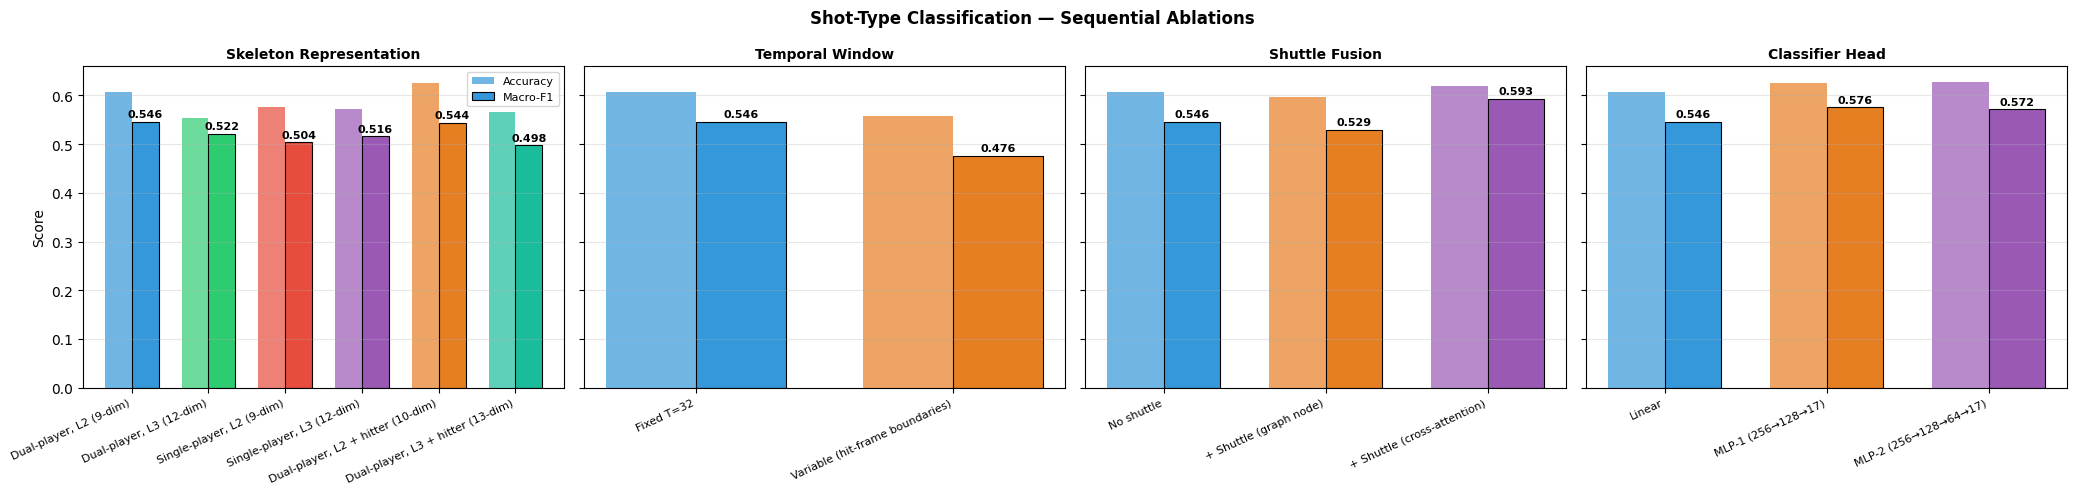

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/ablation_comparison.png


In [18]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

try:
    _abl_dir = ABLATION_DIR
except NameError:
    from src.config import RESULTS_DIR
    _abl_dir = RESULTS_DIR / 'ablations'

# ── Load winners from previous groups ──────────────────────────────────────
_winners_path = _abl_dir / '_winners.json'
if _winners_path.exists():
    with open(_winners_path) as f:
        _w = json.load(f)
else:
    _w = {}

win_A = _w.get('A', 'A1_dual_L2')
win_B = _w.get('B', win_A)
win_C = _w.get('C', win_B)
win_D = _w.get('D', win_C)

# ── Define groups (baselines resolved dynamically) ─────────────────────────
groups = [
    ('Group A: Skeleton Representation', [
        ('A1_dual_L2',   'Dual-player, L2 (9-dim)'),
        ('A2_dual_L3',   'Dual-player, L3 (12-dim)'),
        ('A3_single_L2', 'Single-player, L2 (9-dim)'),
        ('A4_single_L3', 'Single-player, L3 (12-dim)'),
        ('A5_dual_L2_hitter', 'Dual-player, L2 + hitter (10-dim)'),
        ('A6_dual_L3_hitter', 'Dual-player, L3 + hitter (13-dim)'),
    ]),
    ('Group B: Temporal Window', [
        (win_A,                'Fixed T=32 (= A winner)'),
        ('B2_variable_window', 'Variable (hit-frame boundaries)'),
    ]),
    ('Group C: Shuttle Fusion', [
        (win_B,                 'No shuttle (= B winner)'),
        ('C2_shuttle_graph',    '+ Shuttle (graph node)'),
        ('C3_shuttle_crossattn', '+ Shuttle (cross-attention)'),
    ]),
    ('Group D: Classifier Head', [
        (win_C,     'Linear (= C winner)'),
        ('D2_mlp1', 'MLP-1 (256→128→17)'),
        ('D3_mlp2', 'MLP-2 (256→128→64→17)'),
    ]),
]

# Load all results
all_names = set()
for _, items in groups:
    for name, _ in items:
        all_names.add(name)

loaded = {}
for name in all_names:
    p = _abl_dir / f'{name}.json'
    if p.exists():
        with open(p) as f:
            loaded[name] = json.load(f)

# ── Grouped tables ─────────────────────────────────────────────────────────
for group_title, items in groups:
    print(f'\n{"=" * 98}')
    print(f'{group_title}')
    print(f'{"=" * 98}')
    print(f'{"":<4} {"Ablation":<38} {"Accuracy":>10} {"Macro-F1":>10} {"Top-3":>8} {"Top-5":>8} {"Epochs":>8}')
    print(f'{"-" * 98}')
    best_f1 = max((loaded[n]['macro_f1'] for n, _ in items if n in loaded), default=0)
    for i, (name, display) in enumerate(items, 1):
        if name not in loaded:
            print(f'{i:<4} {display:<38} {"(not run)":>10} {"":>10} {"":>8} {"":>8}')
        else:
            r = loaded[name]
            marker = ' *' if r['macro_f1'] == best_f1 else ''
            t3 = r.get('top3_acc', '')
            t5 = r.get('top5_acc', '')
            t3s = f'{t3:>8.4f}' if isinstance(t3, (int, float)) and t3 else f'{"—":>8}'
            t5s = f'{t5:>8.4f}' if isinstance(t5, (int, float)) and t5 else f'{"—":>8}'
            print(f'{i:<4} {display:<38} {r["accuracy"]:>10.4f} {r["macro_f1"]:>10.4f} {t3s} {t5s} {r["stopped_epoch"]:>8}{marker}')

# ── Combined bar chart ──────────────────────────────────────────────────────
n_groups = len(groups)
fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups + 1, 5), sharey=True)
group_colors = [
    ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#e67e22', '#1abc9c'],
    ['#3498db', '#e67e22'],
    ['#3498db', '#e67e22', '#9b59b6'],
    ['#3498db', '#e67e22', '#9b59b6'],
]

for ax, (group_title, items), colors in zip(axes, groups, group_colors):
    names_plot, f1_plot, acc_plot = [], [], []
    for name, display in items:
        if name in loaded:
            clean = display.replace(' (= A winner)', '').replace(' (= B winner)', '').replace(' (= C winner)', '')
            names_plot.append(clean)
            f1_plot.append(loaded[name]['macro_f1'])
            acc_plot.append(loaded[name]['accuracy'])

    if not names_plot:
        ax.set_title(group_title.split(':')[1].strip())
        ax.text(0.5, 0.5, 'No results', ha='center', va='center', transform=ax.transAxes)
        continue

    x = np.arange(len(names_plot))
    w = 0.35
    ax.bar(x - w/2, acc_plot, w, label='Accuracy', color=colors[:len(x)], alpha=0.7)
    bars = ax.bar(x + w/2, f1_plot, w, label='Macro-F1', color=colors[:len(x)], edgecolor='black', lw=0.8)
    for bar, val in zip(bars, f1_plot):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(names_plot, rotation=25, ha='right', fontsize=8)
    ax.set_title(group_title.split(':')[1].strip(), fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
fig.suptitle('Shot-Type Classification — Sequential Ablations', fontsize=12, fontweight='bold')
plt.tight_layout()

fig_path = _abl_dir / 'ablation_comparison.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

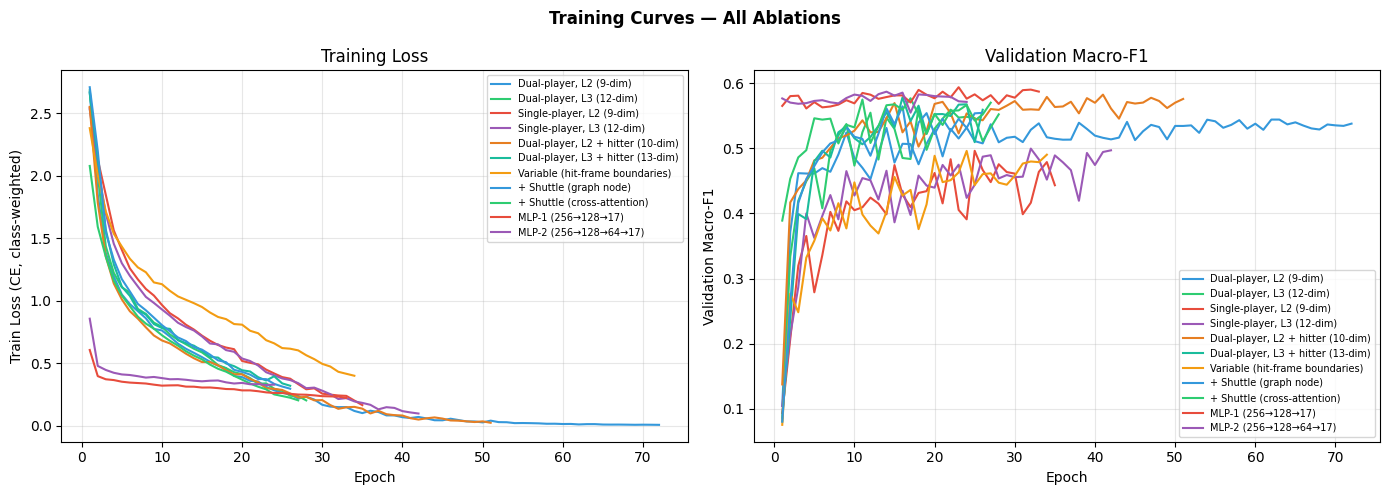

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/ablation_training_curves.png


In [19]:
# ── Training curves overlay ───────────────────────────────────────────────
all_ablation_names = []
for _, items in groups:
    for name, _ in items:
        if name not in [n for n, _ in all_ablation_names]:
            display = [d for n, d in items if n == name][0]
            all_ablation_names.append((name, display))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_all = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#e67e22', '#1abc9c', '#f39c12']

ci = 0
for name, display in all_ablation_names:
    if name in loaded and 'history' in loaded[name]:
        h = loaded[name]['history']
        c = colors_all[ci % len(colors_all)]
        losses = h['train_loss']
        ax1.plot(range(1, len(losses)+1), losses, label=display, color=c, linewidth=1.5)
        if 'val_f1' in h:
            val_f1 = h['val_f1']
            ax2.plot(range(1, len(val_f1)+1), val_f1, label=display, color=c, linewidth=1.5)
        ci += 1

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss (CE, class-weighted)')
ax1.set_title('Training Loss')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Macro-F1')
ax2.set_title('Validation Macro-F1')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

fig.suptitle('Training Curves — All Ablations', fontsize=12, fontweight='bold')
plt.tight_layout()

fig_path2 = _abl_dir / 'ablation_training_curves.png'
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path2}')


## §8 — Diagnostic Analysis

Confusion matrix, class distributions, shuttle coverage, and overfitting analysis.
**Can be run standalone**: restart kernel → run §1–§2 → skip to §8.


Analysing: A1_dual_L2  |  Test F1=0.5461  Acc=0.6060
Config: feat=L2, single=False, hitter=False, var_window=False, shuttle=none
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
Test samples: 1675
Top-1 Accuracy: 0.6060
Top-3 Accuracy: 0.8611
Top-5 Accuracy: 0.9121
Inference done: 1627 samples


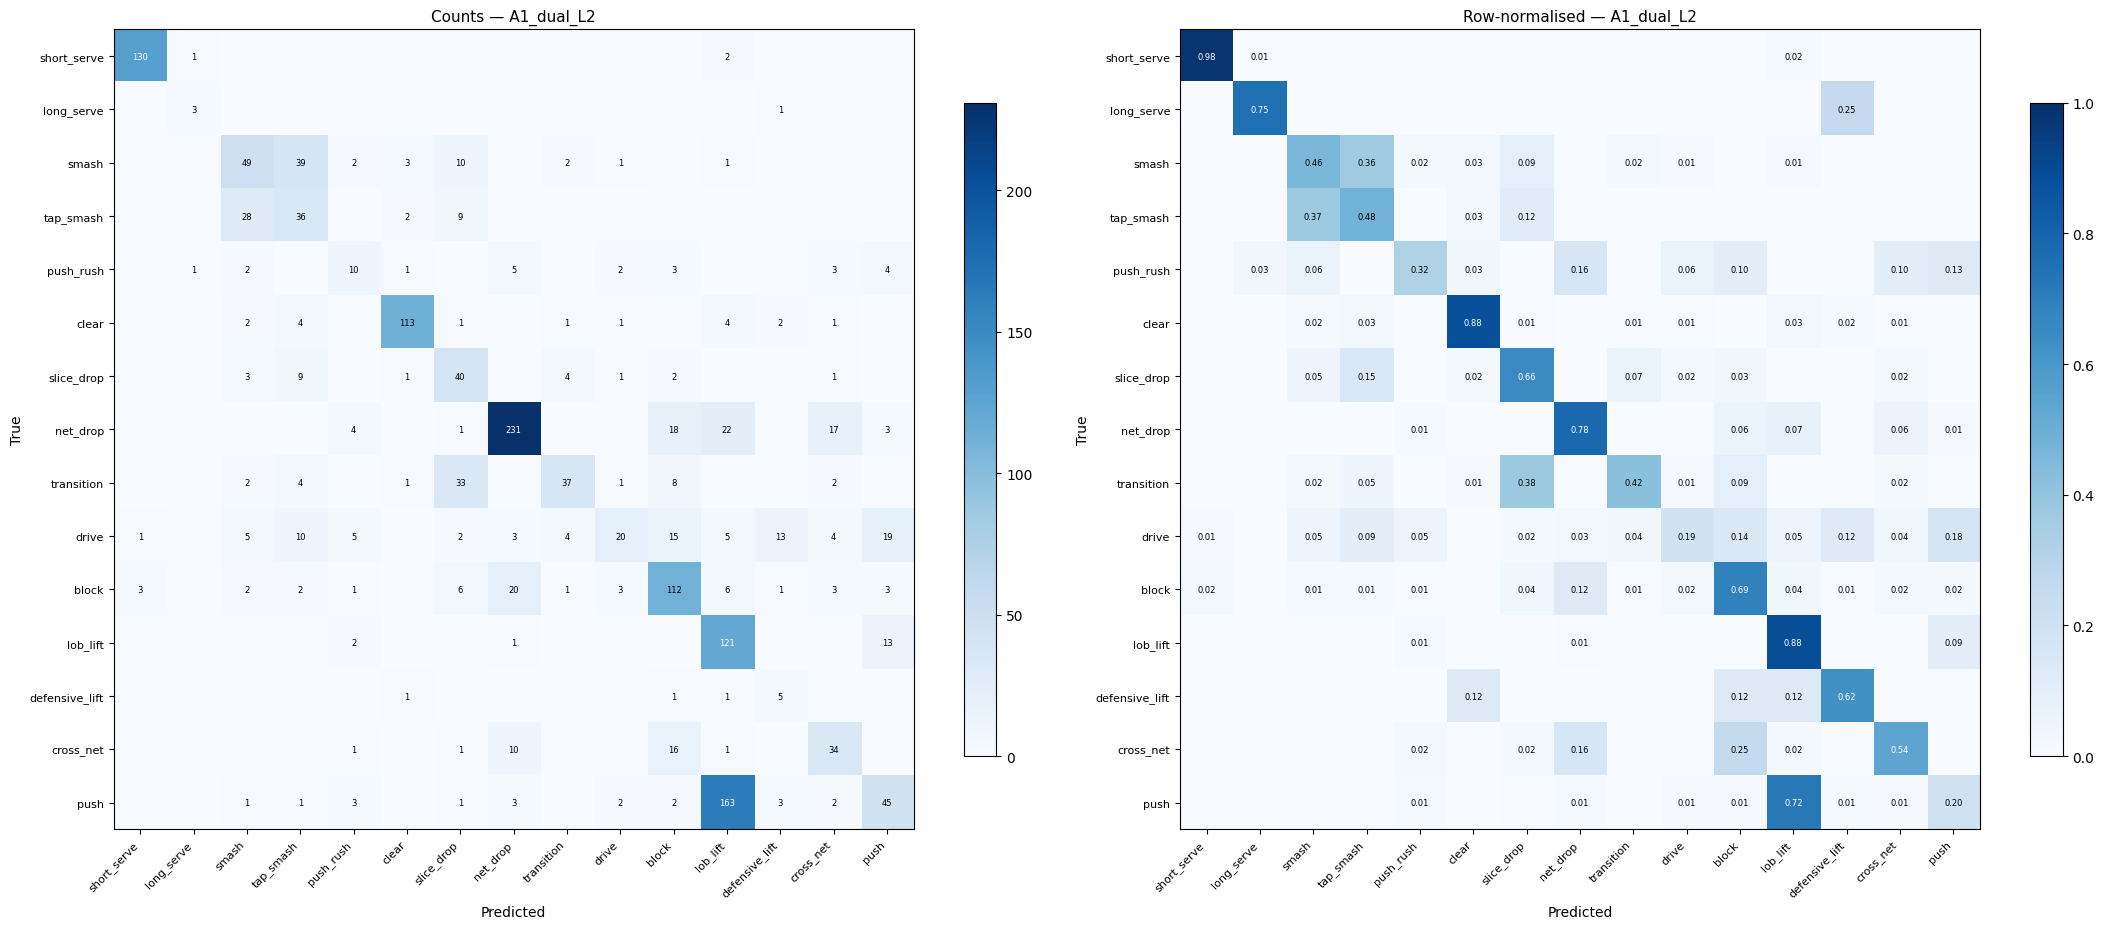

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/confusion_matrix_A1_dual_L2.png

Top 15 confusion pairs (true → predicted : count)
  push               → lob_lift           :  163 (72% of true push)
  smash              → tap_smash          :   39 (36% of true smash)
  transition         → slice_drop         :   33 (38% of true transition)
  tap_smash          → smash              :   28 (37% of true tap_smash)
  net_drop           → lob_lift           :   22 (7% of true net_drop)
  block              → net_drop           :   20 (12% of true block)
  drive              → push               :   19 (18% of true drive)
  net_drop           → block              :   18 (6% of true net_drop)
  net_drop           → cross_net          :   17 (6% of true net_drop)
  cross_net          → block              :   16 (25% of true cross_net)
  drive              → block              :   15 (14% of true drive)
  drive              → defensive_lift     :   13 (12% of true drive)
  lob_lift    

In [20]:
# ══════════════════════════════════════════════════════════════════════════
# 8a — Confusion Matrix (re-run inference on test set from checkpoint)
# ══════════════════════════════════════════════════════════════════════════

import json, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.metrics import confusion_matrix

try:
    _abl_dir = ABLATION_DIR
except NameError:
    from src.config import RESULTS_DIR
    _abl_dir = RESULTS_DIR / 'ablations'

from src.config import (
    FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER, SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
    SHOT_TYPES, NUM_SHOT_TYPES, NUM_NODES, NUM_JOINTS, MODELS_DIR,
)
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.shuttle_cross_attn import ShuttleCrossAttention
try:
    from src.models.shuttle_cross_attn import ShuttleTCN
except ImportError:
    ShuttleTCN = None
from torch.utils.data import DataLoader
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load winner info ──────────────────────────────────────────────────────
_w = json.load(open(_abl_dir / '_winners.json'))
best_name = _w.get('D', _w.get('C', _w.get('B', _w.get('A'))))
best_result = json.load(open(_abl_dir / f'{best_name}.json'))
print(f'Analysing: {best_name}  |  Test F1={best_result["macro_f1"]:.4f}  Acc={best_result["accuracy"]:.4f}')

# ── Detect config from winner chain ───────────────────────────────────────
_a_name = _w.get('A', 'A1_dual_L2')
_b_name = _w.get('B', _a_name)
_c_name = _w.get('C', _b_name)
_feat = 'L3' if 'L3' in _a_name else 'L2'
_single = 'single' in _a_name
_hitter = 'hitter' in _a_name
_var_window = 'variable' in _b_name
_is_shuttle_graph = 'shuttle_graph' in _c_name or 'C2' in _c_name
_is_shuttle_cross = 'crossattn' in _c_name or 'C3' in _c_name
_use_shuttle = _is_shuttle_graph or _is_shuttle_cross
_shuttle_fusion = 'graph' if _is_shuttle_graph else ('cross_attn' if _is_shuttle_cross else 'graph')
_in_ch = FEATURE_DIMS_WITH_HITTER[_feat] if _hitter else FEATURE_DIMS[_feat]

print(f'Config: feat={_feat}, single={_single}, hitter={_hitter}, var_window={_var_window}, '
      f'shuttle={_shuttle_fusion if _use_shuttle else "none"}')

# ── Build test dataset ────────────────────────────────────────────────────
with open(SS_SPLIT_JSON) as f:
    _splits = json.load(f)
TEST_MATCHES = set(_splits['held_out'])

test_ds = ShuttleSetDataset(
    skeleton_dir=SS_SKELETONS_GDINO, shot_window=32, feature_layer=_feat,
    load_shot_types=True, split=None,
    use_shuttle=_use_shuttle, shuttle_dir=SS_SHUTTLES if _use_shuttle else None,
    variable_window=_var_window, shuttle_fusion=_shuttle_fusion,
    use_hitter=_hitter,
)
test_ds.samples = [s for s in test_ds.samples
                   if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in TEST_MATCHES]
print(f'Test samples: {len(test_ds)}')

# ── Load checkpoint & build model ─────────────────────────────────────────
ckpt = torch.load(MODELS_DIR / f'ablation_{best_name}.pt',
                   map_location=device, weights_only=True)

if _is_shuttle_graph:
    graph = GraphBuilder(use_inter_player=True, single_player=False, use_shuttle=True)
    adj = graph.build_adjacency().to(device)
    encoder = STGCN(in_channels=_in_ch, num_nodes=35,
                    adjacency=adj, num_layers=9, base_channels=64,
                    embedding_dim=256, temporal_kernel=9, dropout=0.3).to(device)
else:
    n_nodes = NUM_JOINTS if _single else NUM_NODES
    graph = GraphBuilder(use_inter_player=True, single_player=_single)
    adj = graph.build_adjacency().to(device)
    encoder = STGCN(in_channels=_in_ch, num_nodes=n_nodes,
                    adjacency=adj, num_layers=9, base_channels=64,
                    embedding_dim=256, temporal_kernel=9, dropout=0.3).to(device)
encoder.load_state_dict(ckpt['encoder_state_dict'])
encoder.eval()

cross_attn = None
if _is_shuttle_cross:
    cross_attn = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
    if ShuttleTCN is not None:
        cross_attn.shuttle_tcn = ShuttleTCN(in_channels=4, d_model=128).to(device)
    cross_attn.load_state_dict(ckpt['cross_attn_state_dict'])
    cross_attn.eval()

if 'D3' in best_name:
    head = nn.Sequential(
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64, NUM_SHOT_TYPES),
    ).to(device)
elif 'D2' in best_name:
    head = nn.Sequential(
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, NUM_SHOT_TYPES),
    ).to(device)
else:
    head = nn.Linear(256, NUM_SHOT_TYPES).to(device)
head.load_state_dict(ckpt['head_state_dict'])
head.eval()

# ── Inference ─────────────────────────────────────────────────────────────
def _collate(batch):
    xs, labels, shuttles = [], [], []
    for item in batch:
        xs.append(item[0]); labels.append(item[1])
        if len(item) == 3: shuttles.append(item[2])
    out = [torch.stack(xs), torch.tensor(labels, dtype=torch.long)]
    if shuttles: out.append(torch.stack(shuttles))
    return out

loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=_collate)
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in loader:
        xb, yb = batch[0], batch[1]
        valid = yb >= 0
        if not valid.any(): continue
        xb_v = xb[valid].to(device)
        emb = encoder(xb_v)
        if cross_attn is not None and len(batch) == 3:
            emb = cross_attn(emb, batch[2][valid].to(device))
        all_preds.append(head(emb).cpu())
        all_labels.append(yb[valid])

all_logits = torch.cat(all_preds)
y_true = torch.cat(all_labels).numpy()
y_pred = all_logits.argmax(dim=1).numpy()

# Top-k accuracy
y_true_t = torch.tensor(y_true, dtype=torch.long)
for k in [1, 3, 5]:
    topk_preds = all_logits.topk(k, dim=1).indices
    correct = topk_preds.eq(y_true_t.unsqueeze(1)).any(dim=1)
    print(f'Top-{k} Accuracy: {correct.float().mean().item():.4f}')
print(f'Inference done: {len(y_true)} samples')

# ── Confusion matrix ──────────────────────────────────────────────────────
present_labels = sorted(set(y_true) | set(y_pred))
label_names = [SHOT_TYPES[i] if i < len(SHOT_TYPES) else f'type_{i}'
               for i in present_labels]
cm = confusion_matrix(y_true, y_pred, labels=present_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
for ax, data, title, fmt, vmax in [
    (ax1, cm,      f'Counts — {best_name}', 'd', None),
    (ax2, cm_norm, f'Row-normalised — {best_name}', '.2f', 1),
]:
    kw = {'vmin': 0, 'vmax': vmax} if vmax else {}
    im = ax.imshow(data, interpolation='nearest', cmap='Blues', **kw)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(len(label_names)))
    ax.set_yticks(range(len(label_names)))
    ax.set_xticklabels(label_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(label_names, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    thresh = data.max() * 0.5 if vmax is None else 0.5
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            val = data[i, j]
            show = (val > 0.005) if isinstance(val, float) else (val > 0)
            if show:
                color = 'white' if val > thresh else 'black'
                ax.text(j, i, format(val, fmt), ha='center', va='center',
                        fontsize=6, color=color)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
_cm_path = _abl_dir / f'confusion_matrix_{best_name}.png'
plt.savefig(_cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_cm_path}')

# ── Top confusion pairs ──────────────────────────────────────────────────
print(f'\n{"=" * 70}')
print('Top 15 confusion pairs (true → predicted : count)')
print(f'{"=" * 70}')
pairs = []
for i in range(len(label_names)):
    for j in range(len(label_names)):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], cm_norm[i, j], label_names[i], label_names[j]))
pairs.sort(reverse=True)
for cnt, frac, tc, pc in pairs[:15]:
    print(f'  {tc:<18} → {pc:<18} : {cnt:4d} ({frac:.0%} of true {tc})')

[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
Train: 14385 labeled samples
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
Val: 2077 labeled samples
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
Test: 1627 labeled samples

ID   Shot Type              Train    Tr%    Val   Test   Total
------------------------------------------------------------
0    short_serve              820   5.7%    126    133    1079
1    long_serve                96   0.7%     20      4     120
2    smash                   1132   7.9%    141    107    

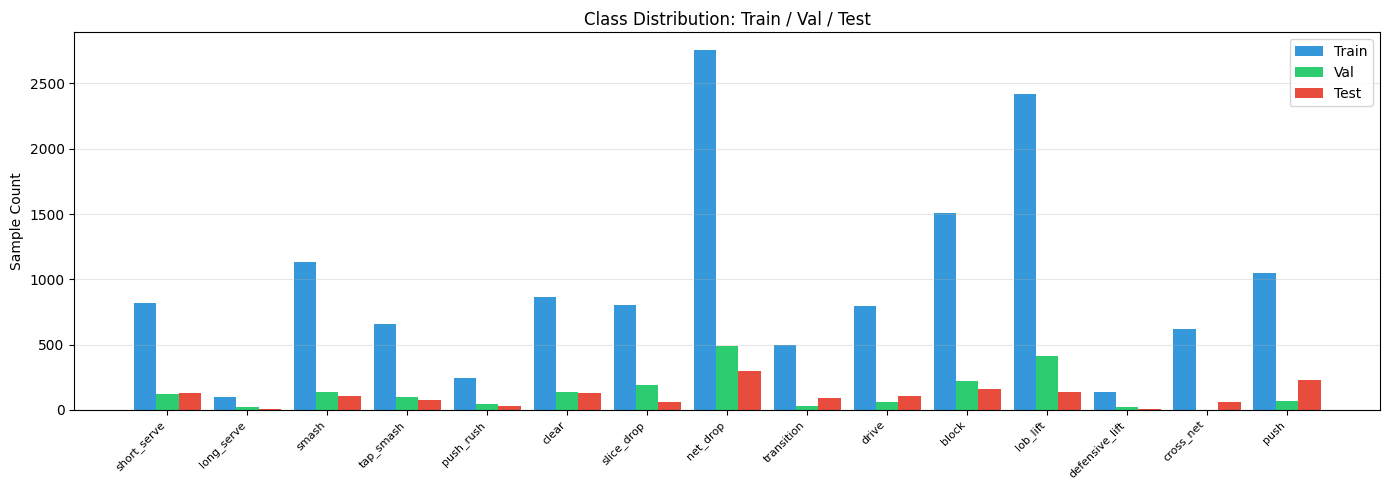

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/class_distribution.png


In [21]:
# ══════════════════════════════════════════════════════════════════════════
# 8b — Class Distribution (train / val / test)
# ══════════════════════════════════════════════════════════════════════════

VAL_MATCH_NAMES = [
    'NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals',
    'Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals',
]
with open(SS_SPLIT_JSON) as f:
    _sp = json.load(f)
TRAIN_M = set(_sp['train']) - set(VAL_MATCH_NAMES)
VAL_M   = set(VAL_MATCH_NAMES)
TEST_M  = set(_sp['held_out'])

def _get_label_counts(match_set, label='split'):
    ds = ShuttleSetDataset(
        skeleton_dir=SS_SKELETONS_GDINO, shot_window=32, feature_layer='L2',
        load_shot_types=True, split=None,
    )
    ds.samples = [s for s in ds.samples
                  if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in match_set]
    labels = [s.get('shot_type_idx') for s in ds.samples
              if s.get('shot_type_idx') is not None]
    counts = Counter(labels)
    print(f'{label}: {len(labels)} labeled samples')
    return counts

train_counts = _get_label_counts(TRAIN_M, 'Train')
val_counts   = _get_label_counts(VAL_M,   'Val')
test_counts  = _get_label_counts(TEST_M,  'Test')

all_classes = sorted(set(train_counts) | set(val_counts) | set(test_counts))
total_train = sum(train_counts.values())
total_val   = sum(val_counts.values())
total_test  = sum(test_counts.values())

print(f'\n{"ID":<4} {"Shot Type":<20} {"Train":>7} {"Tr%":>6} {"Val":>6} {"Test":>6} {"Total":>7}')
print('-' * 60)
for cls_id in all_classes:
    name = SHOT_TYPES[cls_id] if cls_id < len(SHOT_TYPES) else f'type_{cls_id}'
    tr = train_counts.get(cls_id, 0)
    va = val_counts.get(cls_id, 0)
    te = test_counts.get(cls_id, 0)
    pct = tr / total_train * 100 if total_train > 0 else 0
    print(f'{cls_id:<4} {name:<20} {tr:>7} {pct:>5.1f}% {va:>6} {te:>6} {tr+va+te:>7}')
print(f'{"":>4} {"TOTAL":<20} {total_train:>7} {"100%":>6} {total_val:>6} {total_test:>6} '
      f'{total_train+total_val+total_test:>7}')
print(f'\nImbalance ratio (max/min): '
      f'{max(train_counts.values())}/{min(train_counts.values())} = '
      f'{max(train_counts.values())/min(train_counts.values()):.1f}x')

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
names = [SHOT_TYPES[c] if c < len(SHOT_TYPES) else f'type_{c}' for c in all_classes]
x = np.arange(len(all_classes))
w = 0.28
ax.bar(x - w, [train_counts.get(c, 0) for c in all_classes], w,
       label='Train', color='#3498db')
ax.bar(x,     [val_counts.get(c, 0) for c in all_classes],   w,
       label='Val',   color='#2ecc71')
ax.bar(x + w, [test_counts.get(c, 0) for c in all_classes],  w,
       label='Test',  color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sample Count')
ax.set_title('Class Distribution: Train / Val / Test')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
_dist_path = _abl_dir / 'class_distribution.png'
plt.savefig(_dist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_dist_path}')



[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
Checking shuttle coverage (2000 of 18901 samples)...

Samples WITH shuttle data: 1755/2000 (87.8%)
Samples with NO data:     245/2000 (12.2%)

Frame-level density (samples with data):
  Mean:   74.1% of frames have shuttle coords
  Median: 81.2%
  Min:    3.1%   Max: 100.0%


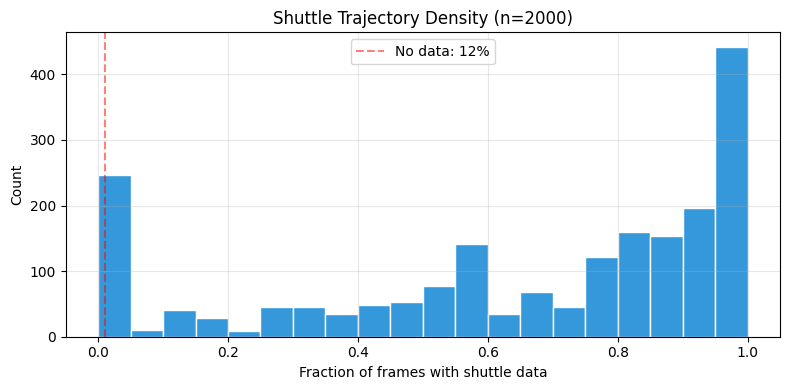

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/shuttle_coverage.png


In [22]:
# ══════════════════════════════════════════════════════════════════════════
# 8c — Shuttle Coverage Analysis
# ══════════════════════════════════════════════════════════════════════════

_all_matches = TRAIN_M | VAL_M | TEST_M
ds_shuttle = ShuttleSetDataset(
    skeleton_dir=SS_SKELETONS_GDINO, shot_window=32, feature_layer='L2',
    load_shot_types=True, split=None,
    use_shuttle=True, shuttle_dir=SS_SHUTTLES, shuttle_fusion='cross_attn',
)
ds_shuttle.samples = [s for s in ds_shuttle.samples
                      if isinstance(s, dict)
                      and Path(s.get('skel_dir', '')).name in _all_matches]

n_check = min(len(ds_shuttle), 2000)
rng = np.random.default_rng(42)
indices = rng.choice(len(ds_shuttle), size=n_check, replace=False)

print(f'Checking shuttle coverage ({n_check} of {len(ds_shuttle)} samples)...')
n_has = 0
densities = []
for idx in indices:
    item = ds_shuttle[int(idx)]
    if len(item) >= 3:
        sh = item[2].numpy() if isinstance(item[2], torch.Tensor) else item[2]
        has = np.any(sh[:2] != 0)
        n_has += int(has)
        densities.append(np.any(sh[:2] != 0, axis=0).mean())

pct_cov = n_has / n_check * 100
print(f'\nSamples WITH shuttle data: {n_has}/{n_check} ({pct_cov:.1f}%)')
print(f'Samples with NO data:     {n_check - n_has}/{n_check} ({100-pct_cov:.1f}%)')

densities = np.array(densities)
pos = densities[densities > 0]
if len(pos) > 0:
    print(f'\nFrame-level density (samples with data):')
    print(f'  Mean:   {pos.mean():.1%} of frames have shuttle coords')
    print(f'  Median: {np.median(pos):.1%}')
    print(f'  Min:    {pos.min():.1%}   Max: {pos.max():.1%}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(densities, bins=20, color='#3498db', edgecolor='white')
ax.set_xlabel('Fraction of frames with shuttle data')
ax.set_ylabel('Count')
ax.set_title(f'Shuttle Trajectory Density (n={n_check})')
ax.axvline(x=0.01, color='red', ls='--', alpha=0.5,
           label=f'No data: {100-pct_cov:.0f}%')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
_sh_path = _abl_dir / 'shuttle_coverage.png'
plt.savefig(_sh_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_sh_path}')



Name                           Ep  FinalLoss  BestValF1   TestF1      Gap
---------------------------------------------------------------------------
A1_dual_L2                     72     0.0077     0.5442   0.5461  -0.0019
A2_dual_L3                     28     0.2031     0.5613   0.5216  +0.0397
A3_single_L2                   35     0.1651     0.4963   0.5037  -0.0074
A4_single_L3                   42     0.0981     0.4996   0.5158  -0.0162
A5_dual_L2_hitter              51     0.0241     0.5826   0.5440  +0.0386
A6_dual_L3_hitter              26     0.3200     0.5784   0.4978  +0.0806
B2_variable_window             34     0.4001     0.4961   0.4758  +0.0203
C2_shuttle_graph               26     0.2964     0.5645   0.5292  +0.0353
C3_shuttle_crossattn           27     0.2034     0.5769   0.5929  -0.0160
D2_mlp1                        33     0.2222     0.5939   0.5759  +0.0180
D3_mlp2                        24     0.3288     0.5871   0.5716  +0.0155


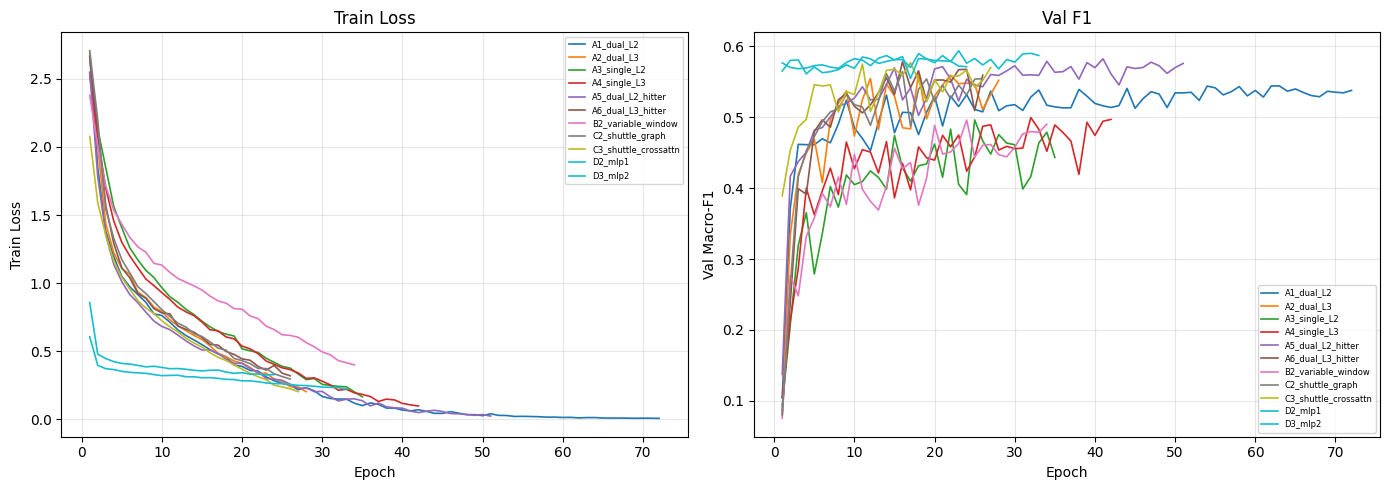

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/overfitting_analysis.png


In [23]:
# ══════════════════════════════════════════════════════════════════════════
# 8d — Overfitting Analysis
# ══════════════════════════════════════════════════════════════════════════

all_results = {}
for p in _abl_dir.glob('*.json'):
    if p.stem.startswith('_'): continue
    try:
        all_results[p.stem] = json.load(open(p))
    except: pass

print(f'{"Name":<28} {"Ep":>4} {"FinalLoss":>10} {"BestValF1":>10} {"TestF1":>8} {"Gap":>8}')
print('-' * 75)
for name in sorted(all_results):
    r = all_results[name]
    h = r.get('history', {})
    fl = h['train_loss'][-1] if h.get('train_loss') else None
    bv = r.get('best_val_f1')
    tf = r.get('macro_f1')
    gap = bv - tf if bv is not None and tf is not None else None
    fl_s  = f'{fl:>10.4f}' if fl is not None else f'{"N/A":>10}'
    bv_s  = f'{bv:>10.4f}' if bv is not None else f'{"N/A":>10}'
    tf_s  = f'{tf:>8.4f}'  if tf is not None else f'{"N/A":>8}'
    gap_s = f'{gap:>+8.4f}' if gap is not None else f'{"N/A":>8}'
    print(f'{name:<28} {r["stopped_epoch"]:>4} {fl_s} {bv_s} {tf_s} {gap_s}')

# ── Training trajectories ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
configs = sorted(all_results.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(configs)))

for name, c in zip(configs, colors):
    h = all_results[name].get('history', {})
    if h.get('train_loss'):
        ep = range(1, len(h['train_loss'])+1)
        ax1.plot(ep, h['train_loss'], label=name, color=c, lw=1.2)
    if h.get('val_f1'):
        ep = range(1, len(h['val_f1'])+1)
        ax2.plot(ep, h['val_f1'], label=name, color=c, lw=1.2)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train Loss')
ax1.set_title('Train Loss'); ax1.legend(fontsize=6); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Macro-F1')
ax2.set_title('Val F1'); ax2.legend(fontsize=6); ax2.grid(True, alpha=0.3)
plt.tight_layout()
_ov_path = _abl_dir / 'overfitting_analysis.png'
plt.savefig(_ov_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_ov_path}')



In [24]:
# ══════════════════════════════════════════════════════════════════════════
# 8e — Diagnostic Summary
# ══════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('DIAGNOSTIC SUMMARY')
print('=' * 70)

print(f'\n1. BEST CONFIG: {best_name}')
print(f'   Test Macro-F1: {best_result["macro_f1"]:.4f}')
print(f'   Test Accuracy: {best_result["accuracy"]:.4f}')
print(f'   Top-3 Acc:     {best_result.get("top3_acc", "N/A")}')
print(f'   Top-5 Acc:     {best_result.get("top5_acc", "N/A")}')

print(f'\n2. CLASS IMBALANCE:')
print(f'   Largest class:  {max(train_counts.values())} samples')
print(f'   Smallest class: {min(train_counts.values())} samples')
print(f'   Ratio: {max(train_counts.values())/min(train_counts.values()):.1f}x')

print(f'\n3. SHUTTLE COVERAGE: {pct_cov:.1f}% of samples have trajectory data')

print(f'\n4. TOP 5 CONFUSION PAIRS:')
for cnt, frac, tc, pc in pairs[:5]:
    print(f'   {tc} → {pc}: {cnt} ({frac:.0%})')

print(f'\n5. WORST CLASSES BY F1:')
per_class = best_result.get('per_class', {})
class_f1s = []
for cls_name in SHOT_TYPES:
    if cls_name in per_class:
        f1 = per_class[cls_name].get('f1-score', 0)
        sup = per_class[cls_name].get('support', 0)
        class_f1s.append((f1, sup, cls_name))
class_f1s.sort()
for f1, sup, name in class_f1s[:5]:
    print(f'   {name:<18} F1={f1:.2f} (n={sup})')

print(f'\n6. OVERFITTING:')
h = best_result.get('history', {})
if h.get('train_loss'):
    bv = best_result['best_val_f1']
    tf = best_result['macro_f1']
    gap = bv - tf
    print(f'   Final train loss: {h["train_loss"][-1]:.4f}')
    print(f'   Best val F1:      {bv:.4f}')
    print(f'   Test F1:          {tf:.4f}')
    print(f'   Val→Test gap:     {gap:+.4f} ({"OK" if abs(gap) < 0.03 else "notable gap"})')

print(f'\n7. EVALUATION CAVEAT:')
print(f'   Test set = 2 matches ({len(y_true)} shots)')
print(f'   Ablation differences < ~0.02 F1 may not be reliable')
print(f'   Consider leave-2-out CV for robust comparison')




DIAGNOSTIC SUMMARY

1. BEST CONFIG: A1_dual_L2
   Test Macro-F1: 0.5461
   Test Accuracy: 0.6060
   Top-3 Acc:     0.8611
   Top-5 Acc:     0.9121

2. CLASS IMBALANCE:
   Largest class:  2753 samples
   Smallest class: 96 samples
   Ratio: 28.7x

3. SHUTTLE COVERAGE: 87.8% of samples have trajectory data

4. TOP 5 CONFUSION PAIRS:
   push → lob_lift: 163 (72%)
   smash → tap_smash: 39 (36%)
   transition → slice_drop: 33 (38%)
   tap_smash → smash: 28 (37%)
   net_drop → lob_lift: 22 (7%)

5. WORST CLASSES BY F1:
   push               F1=0.29 (n=226.0)
   drive              F1=0.29 (n=106.0)
   defensive_lift     F1=0.30 (n=8.0)
   push_rush          F1=0.34 (n=31.0)
   tap_smash          F1=0.40 (n=75.0)

6. OVERFITTING:
   Final train loss: 0.0077
   Best val F1:      0.5442
   Test F1:          0.5461
   Val→Test gap:     -0.0019 (OK)

7. EVALUATION CAVEAT:
   Test set = 2 matches (1627 shots)
   Ablation differences < ~0.02 F1 may not be reliable
   Consider leave-2-out CV for robu

## §9 — Cross-Validation (Leave-2-Matches-Out)

Run CV on the 19 training-pool matches (2 held-out test matches stay untouched).
Each fold holds out 2 matches as val; remaining 17 train. ~10 folds.

**CV_MODE** controls scope vs compute:
| Mode | What it CVs | Folds × configs | ~Time |
|------|-------------|-----------------|-------|
| `'winner_only'` | Final winning config only | 10 × 1 | ~2.5h |
| `'contested'` | Group A (6) + Group C (3) | 10 × 9 | ~12h |
| `'full_cascade'` | Full A→B→C cascade | 10 × 11 | ~18h |

Set `CV_MODE` in the code cell below before running.

In [25]:
# ══════════════════════════════════════════════════════════════════════════
# §9 — Cross-Validation (Leave-2-Matches-Out)
# ══════════════════════════════════════════════════════════════════════════
#
# CV_MODE options:
#   'winner_only'   — CV the final §3–§6 winner config only (~2.5h)
#   'contested'     — Group A (6 configs) + Group C (3 configs)  (~12h)
#   'full_cascade'  — Full A→B→C cascade per fold               (~18h)

CV_MODE = 'winner_only'  # ← change this

import json, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from collections import defaultdict
from torch.utils.data import DataLoader

# Re-import in case running standalone (restart → §1–§2 → skip to §9)
try:
    _ = ABLATION_DIR
except NameError:
    from src.config import (
        get_config, FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER,
        SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
        SHOT_TYPES, NUM_SHOT_TYPES, NUM_NODES, NUM_JOINTS,
        MODELS_DIR, RESULTS_DIR,
    )
    from src.data.graph_builder import GraphBuilder
    from src.data.dataset import ShuttleSetDataset
    from src.models.stgcn_model import STGCN
    from src.models.shuttle_cross_attn import ShuttleCrossAttention, ShuttleTCN
    ABLATION_DIR = RESULTS_DIR / 'ablations'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    N_CLASSES = NUM_SHOT_TYPES
    SEED = 42

# ── Generate ~10 folds from the 19 training-pool matches ─────────────────
with open(SS_SPLIT_JSON) as f:
    _sp = json.load(f)

ALL_TRAIN_POOL = sorted(_sp['train'])   # 19 matches
TEST_MATCHES_CV = set(_sp['held_out'])  # 2 held-out (fixed, never used in CV)

rng = np.random.RandomState(SEED)
_shuffled = list(ALL_TRAIN_POOL)
rng.shuffle(_shuffled)

# Partition into folds of 2 (last fold gets 1 if 19 is odd)
CV_FOLDS = []
for i in range(0, len(_shuffled), 2):
    val_pair = _shuffled[i:i+2]
    train_set = set(ALL_TRAIN_POOL) - set(val_pair)
    CV_FOLDS.append((set(val_pair), train_set))

print(f'CV mode: {CV_MODE}')
print(f'{len(CV_FOLDS)} folds, {len(ALL_TRAIN_POOL)} train-pool, '
      f'{len(TEST_MATCHES_CV)} held-out test')
for fi, (v, t) in enumerate(CV_FOLDS):
    print(f'  Fold {fi}: val={sorted(v)}')


# ── CV training function (no checkpointing, no test eval) ────────────────
def cv_train_eval(name, train_matches, val_matches, build_fn, epochs=EPOCHS):
    """
    Train one config on train_matches, return best val macro-F1.
    build_fn(train_m, val_m) -> (train_ds, val_ds, encoder, head, cross_attn|None)
    """
    train_ds, val_ds, encoder, head, cross_attn = build_fn(train_matches, val_matches)
    use_ca = cross_attn is not None
    cfn = collate_fn_shuttle if use_ca else collate_fn

    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=True, drop_last=True, collate_fn=cfn)

    class_weights = compute_class_weights(train_ds).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    params = list(encoder.parameters()) + list(head.parameters())
    if use_ca:
        params += list(cross_attn.parameters())
    optimizer = optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_f1 = -1.0
    no_improve = 0

    for epoch in range(epochs):
        encoder.train(); head.train()
        if use_ca:
            cross_attn.train()
        for batch in loader:
            if use_ca:
                xb, yb, sb = batch
                sb = sb.to(device)
            else:
                xb, yb = batch
            valid = yb >= 0
            if not valid.any():
                continue
            xb_v = xb[valid].to(device)
            yb_v = yb[valid].to(device)
            emb = encoder(xb_v)
            if use_ca:
                emb = cross_attn(emb, sb[valid])
            loss = criterion(head(emb), yb_v)
            optimizer.zero_grad()
            loss.backward()
            if use_ca:
                torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            optimizer.step()
        scheduler.step()

        val_f1, _, _, _, _ = evaluate(encoder, head, val_ds, cross_attn)
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                break

    return best_val_f1


# ── Builder functions ─────────────────────────────────────────────────────

def _build_A(feat, single, hitter):
    def build(train_m, val_m):
        tr = make_dataset(train_m, feature_layer=feat, use_hitter=hitter)
        va = make_dataset(val_m, feature_layer=feat, use_hitter=hitter)
        if single:
            tr, va = SinglePlayerWrapper(tr), SinglePlayerWrapper(va)
        in_ch = FEATURE_DIMS_WITH_HITTER[feat] if hitter else FEATURE_DIMS[feat]
        n_nodes = NUM_JOINTS if single else NUM_NODES
        enc = build_encoder(in_channels=in_ch, num_nodes=n_nodes, single_player=single)
        hd = nn.Linear(256, N_CLASSES).to(device)
        return tr, va, enc, hd, None
    return build

def _build_B2(feat, single, hitter):
    def build(train_m, val_m):
        tr = make_dataset(train_m, feature_layer=feat, use_hitter=hitter, variable_window=True)
        va = make_dataset(val_m, feature_layer=feat, use_hitter=hitter, variable_window=True)
        if single:
            tr, va = SinglePlayerWrapper(tr), SinglePlayerWrapper(va)
        in_ch = FEATURE_DIMS_WITH_HITTER[feat] if hitter else FEATURE_DIMS[feat]
        n_nodes = NUM_JOINTS if single else NUM_NODES
        enc = build_encoder(in_channels=in_ch, num_nodes=n_nodes, single_player=single)
        hd = nn.Linear(256, N_CLASSES).to(device)
        return tr, va, enc, hd, None
    return build

def _build_C2(feat, single, hitter, var_window):
    def build(train_m, val_m):
        kw = dict(feature_layer=feat, use_hitter=hitter, variable_window=var_window,
                  use_shuttle=True, shuttle_fusion='graph')
        tr, va = make_dataset(train_m, **kw), make_dataset(val_m, **kw)
        in_ch = FEATURE_DIMS_WITH_HITTER[feat] if hitter else FEATURE_DIMS[feat]
        graph = GraphBuilder(use_inter_player=True, single_player=False, use_shuttle=True)
        adj = graph.build_adjacency().to(device)
        enc = STGCN(in_channels=in_ch, num_nodes=35, adjacency=adj,
                    num_layers=9, base_channels=64, embedding_dim=256,
                    temporal_kernel=9, dropout=0.3).to(device)
        hd = nn.Linear(256, N_CLASSES).to(device)
        return tr, va, enc, hd, None
    return build

def _build_C3(feat, single, hitter, var_window):
    def build(train_m, val_m):
        kw = dict(feature_layer=feat, use_hitter=hitter, variable_window=var_window,
                  use_shuttle=True, shuttle_fusion='cross_attn')
        tr, va = make_dataset(train_m, **kw), make_dataset(val_m, **kw)
        in_ch = FEATURE_DIMS_WITH_HITTER[feat] if hitter else FEATURE_DIMS[feat]
        enc = build_encoder(in_channels=in_ch, num_nodes=NUM_NODES)
        ca = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
        ca.shuttle_tcn = ShuttleTCN(in_channels=4, d_model=128).to(device)
        hd = nn.Linear(256, N_CLASSES).to(device)
        return tr, va, enc, hd, ca
    return build


# ── Detect winning config from §3–§6 results ─────────────────────────────
_winners_path = ABLATION_DIR / '_winners.json'
if _winners_path.exists():
    with open(_winners_path) as f:
        _w = json.load(f)
else:
    _w = {}

_a_name = _w.get('A', 'A1_dual_L2')
_b_name = _w.get('B', _a_name)
_c_name = _w.get('C', _b_name)
_win_feat    = 'L3' if 'L3' in _a_name else 'L2'
_win_single  = 'single' in _a_name
_win_hitter  = 'hitter' in _a_name
_win_var     = 'variable' in _b_name
_win_shuttle = 'graph' if 'graph' in _c_name else ('cross_attn' if 'cross' in _c_name else None)

# Determine the builder for the overall winner
def _winner_builder():
    if _win_shuttle == 'graph':
        return _build_C2(_win_feat, _win_single, _win_hitter, _win_var)
    elif _win_shuttle == 'cross_attn':
        return _build_C3(_win_feat, _win_single, _win_hitter, _win_var)
    elif _win_var:
        return _build_B2(_win_feat, _win_single, _win_hitter)
    else:
        return _build_A(_win_feat, _win_single, _win_hitter)


# ── Assemble configs to CV based on mode ──────────────────────────────────
A_CONFIGS = {
    'A1_dual_L2':        _build_A('L2', False, False),
    'A2_dual_L3':        _build_A('L3', False, False),
    'A3_single_L2':      _build_A('L2', True, False),
    'A4_single_L3':      _build_A('L3', True, False),
    'A5_dual_L2_hitter': _build_A('L2', False, True),
    'A6_dual_L3_hitter': _build_A('L3', False, True),
}

cv_results = defaultdict(list)  # name → [val_f1 per fold]
t0 = time.time()

for fi, (val_m, train_m) in enumerate(CV_FOLDS):
    print(f'\n{"="*70}')
    print(f'Fold {fi+1}/{len(CV_FOLDS)} — val: {sorted(val_m)}')
    print(f'{"="*70}')

    if CV_MODE == 'winner_only':
        # ── Only CV the overall winner config ─────────────────────────
        winner_name = _w.get('D', _w.get('C', _w.get('B', _w.get('A', 'A1_dual_L2'))))
        torch.manual_seed(SEED + fi)
        f1 = cv_train_eval(winner_name, train_m, val_m, _winner_builder())
        cv_results[winner_name].append(f1)
        print(f'  {winner_name}: val F1 = {f1:.4f}')

    else:
        # ── Group A (always run in contested / full_cascade) ──────────
        fold_A_scores = {}
        for aname, builder in A_CONFIGS.items():
            torch.manual_seed(SEED + fi)
            f1 = cv_train_eval(aname, train_m, val_m, builder)
            cv_results[aname].append(f1)
            fold_A_scores[aname] = f1
            print(f'  {aname}: val F1 = {f1:.4f}')

        # Pick fold-local A winner for downstream groups
        best_a = max(fold_A_scores, key=fold_A_scores.get)
        _feat = 'L3' if 'L3' in best_a else 'L2'
        _single = 'single' in best_a
        _hitter = 'hitter' in best_a

        if CV_MODE == 'full_cascade':
            # ── Group B ───────────────────────────────────────────────
            cv_results['B1_fixed'].append(fold_A_scores[best_a])

            torch.manual_seed(SEED + fi)
            b2_f1 = cv_train_eval('B2_variable', train_m, val_m,
                                   _build_B2(_feat, _single, _hitter))
            cv_results['B2_variable'].append(b2_f1)
            print(f'  B2_variable: val F1 = {b2_f1:.4f}')
            _var_window = b2_f1 > fold_A_scores[best_a]
        else:
            # contested mode: use the global B winner setting
            _var_window = _win_var

        # ── Group C (run in both contested + full_cascade) ────────────
        if CV_MODE == 'full_cascade':
            best_b_f1 = max(fold_A_scores[best_a],
                            cv_results['B2_variable'][-1] if 'B2_variable' in cv_results else 0)
            cv_results['C1_no_shuttle'].append(best_b_f1)

        torch.manual_seed(SEED + fi)
        c2_f1 = cv_train_eval('C2_shuttle_graph', train_m, val_m,
                               _build_C2(_feat, _single, _hitter, _var_window))
        cv_results['C2_shuttle_graph'].append(c2_f1)
        print(f'  C2_shuttle_graph: val F1 = {c2_f1:.4f}')

        torch.manual_seed(SEED + fi)
        c3_f1 = cv_train_eval('C3_shuttle_crossattn', train_m, val_m,
                               _build_C3(_feat, _single, _hitter, _var_window))
        cv_results['C3_shuttle_crossattn'].append(c3_f1)
        print(f'  C3_shuttle_crossattn: val F1 = {c3_f1:.4f}')

elapsed = time.time() - t0
print(f'\n\nCV completed in {elapsed/60:.1f} min')

# ── Summary table ─────────────────────────────────────────────────────────
print(f'\n{"="*80}')
print(f'Cross-Validation Results — {CV_MODE} ({len(CV_FOLDS)} folds)')
print(f'{"="*80}')
print(f'{"Ablation":<28} {"Mean F1":>10} {"± Std":>10} {"Min":>8} {"Max":>8} {"N":>4}')
print(f'{"-"*72}')

display_order = [
    'A1_dual_L2', 'A2_dual_L3', 'A3_single_L2', 'A4_single_L3',
    'A5_dual_L2_hitter', 'A6_dual_L3_hitter',
    'B1_fixed', 'B2_variable',
    'C1_no_shuttle', 'C2_shuttle_graph', 'C3_shuttle_crossattn',
]
# Also include any winner-only names not in display_order
for name in cv_results:
    if name not in display_order:
        display_order.append(name)

best_mean = -1
best_name_cv = ''
for name in display_order:
    if name not in cv_results:
        continue
    scores = cv_results[name]
    mean_f1 = np.mean(scores)
    std_f1 = np.std(scores)
    if mean_f1 > best_mean:
        best_mean = mean_f1
        best_name_cv = name
    marker = ' *' if mean_f1 >= best_mean else ''
    print(f'{name:<28} {mean_f1:>10.4f} {std_f1:>10.4f} {min(scores):>8.4f} {max(scores):>8.4f} {len(scores):>4}{marker}')

print(f'\nBest by mean val F1: {best_name_cv} ({best_mean:.4f} ± {np.std(cv_results[best_name_cv]):.4f})')

# Save CV results
cv_save = {name: {'scores': [round(s, 4) for s in scores],
                   'mean': round(float(np.mean(scores)), 4),
                   'std': round(float(np.std(scores)), 4)}
           for name, scores in cv_results.items()}
cv_save['_meta'] = {
    'cv_mode': CV_MODE,
    'n_folds': len(CV_FOLDS),
    'folds': [{'val': sorted(v), 'train_size': len(t)} for v, t in CV_FOLDS],
    'elapsed_min': round(elapsed / 60, 1),
}
cv_path = ABLATION_DIR / '_cv_results.json'
with open(cv_path, 'w') as f:
    json.dump(cv_save, f, indent=2)
print(f'Saved: {cv_path}')

CV mode: winner_only
10 folds, 19 train-pool, 2 held-out test
  Fold 0: val=['Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_OPEN_2021_QuarterFinals', 'CHOU_Tien_Chen_Jonatan_CHRISTIE_Indonesia_Open_2019_Quarter-finals']
  Fold 1: val=['Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_TOUR_FINALS_2020_Finals', 'Viktor_AXELSEN _SHI_Yu_Qi_All_England_Open_2020_QuarterFinals']
  Fold 2: val=['NG_Ka_Long_Angus_Jonatan_CHRISTIE_Malaysia_Masters_2020_QuarterFinals', 'Viktor_Axelsen_Jonatan_Christie_YONEX_Thailand_Open_2021_QuarterFinals']
  Fold 3: val=['Anthony_Sinisuka_GINTING_Viktor_AXELSEN _Indonesia_Masters_2020_SemiFinals', 'Viktor_AXELSEN_NG_Ka_Long_Angus_Malaysia_Masters_2020_SemiFinals']
  Fold 4: val=['Viktor_Axelsen_Hans-Kristian_Solberg_VIittinghus_TOYOTA_THAILAND_OPEN_2021_Finals', 'Viktor_Axelsen_Liew_Daren_TOYOTA_THAILAND_OPEN_2021_QuarterFinals']
  Fold 5: val=['Anthony_Sinisuka_GINTING_Anders_ANTONSEN_Indonesia_Masters_2020_Final', 'Ng_Ka_Long_Angus_Kidambi_Srikanth_HSBC_BWF_WORL

## §10 — Per-Shot Inference Export

Run the best model on the **held-out test set** and export per-shot predictions as JSON:
```json
[{"match": "...", "rally": "s1r3", "ball_round": 5, "frame_num": 1234,
  "true": "push", "pred": "push", "correct": true,
  "probs": {"push": 0.8, "smash": 0.15, ...}}, ...]
```
This JSON is served by `badminton_server.py` and displayed in the UI.

In [26]:
# ══════════════════════════════════════════════════════════════════════════
# §10 — Per-Shot Inference Export
# ══════════════════════════════════════════════════════════════════════════

import json, torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader

# Re-import in case running standalone
try:
    _ = ABLATION_DIR
except NameError:
    from src.config import (
        FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER, SS_SKELETONS_GDINO, SS_SHUTTLES,
        SS_SPLIT_JSON, SHOT_TYPES, NUM_SHOT_TYPES, NUM_NODES, NUM_JOINTS,
        MODELS_DIR, RESULTS_DIR,
    )
    from src.data.graph_builder import GraphBuilder
    from src.data.dataset import ShuttleSetDataset
    from src.models.stgcn_model import STGCN
    from src.models.shuttle_cross_attn import ShuttleCrossAttention
    try:
        from src.models.shuttle_cross_attn import ShuttleTCN
    except ImportError:
        ShuttleTCN = None
    ABLATION_DIR = RESULTS_DIR / 'ablations'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load winner config ────────────────────────────────────────────────────
_w = json.load(open(ABLATION_DIR / '_winners.json'))
best_name = _w.get('D', _w.get('C', _w.get('B', _w.get('A'))))
print(f'Exporting predictions for: {best_name}')

_a_name = _w.get('A', 'A1_dual_L2')
_b_name = _w.get('B', _a_name)
_c_name = _w.get('C', _b_name)
_feat = 'L3' if 'L3' in _a_name else 'L2'
_single = 'single' in _a_name
_hitter = 'hitter' in _a_name
_var_window = 'variable' in _b_name
_is_shuttle_graph = 'shuttle_graph' in _c_name or 'C2' in _c_name
_is_shuttle_cross = 'crossattn' in _c_name or 'C3' in _c_name
_use_shuttle = _is_shuttle_graph or _is_shuttle_cross
_shuttle_fusion = 'graph' if _is_shuttle_graph else ('cross_attn' if _is_shuttle_cross else 'graph')
_in_ch = FEATURE_DIMS_WITH_HITTER[_feat] if _hitter else FEATURE_DIMS[_feat]

# ── Build dataset (ALL matches — train + test) ───────────────────────────
with open(SS_SPLIT_JSON) as f:
    _splits = json.load(f)
ALL_MATCHES = set(_splits['train']) | set(_splits['held_out'])

ds = ShuttleSetDataset(
    skeleton_dir=SS_SKELETONS_GDINO, shot_window=32, feature_layer=_feat,
    load_shot_types=True, split=None,
    use_shuttle=_use_shuttle, shuttle_dir=SS_SHUTTLES if _use_shuttle else None,
    variable_window=_var_window, shuttle_fusion=_shuttle_fusion,
    use_hitter=_hitter,
)
# Keep only samples with labels and from known matches
ds.samples = [s for s in ds.samples
              if isinstance(s, dict)
              and s.get('shot_type_idx') is not None
              and Path(s.get('skel_dir', '')).name in ALL_MATCHES]
print(f'Total labeled samples: {len(ds)}')

# ── Load model ────────────────────────────────────────────────────────────
ckpt = torch.load(MODELS_DIR / f'ablation_{best_name}.pt',
                   map_location=device, weights_only=True)

if _is_shuttle_graph:
    graph = GraphBuilder(use_inter_player=True, single_player=False, use_shuttle=True)
    adj = graph.build_adjacency().to(device)
    encoder = STGCN(in_channels=_in_ch, num_nodes=35, adjacency=adj,
                    num_layers=9, base_channels=64, embedding_dim=256,
                    temporal_kernel=9, dropout=0.3).to(device)
else:
    n_nodes = NUM_JOINTS if _single else NUM_NODES
    graph = GraphBuilder(use_inter_player=True, single_player=_single)
    adj = graph.build_adjacency().to(device)
    encoder = STGCN(in_channels=_in_ch, num_nodes=n_nodes, adjacency=adj,
                    num_layers=9, base_channels=64, embedding_dim=256,
                    temporal_kernel=9, dropout=0.3).to(device)
encoder.load_state_dict(ckpt['encoder_state_dict'])
encoder.eval()

cross_attn = None
if _is_shuttle_cross:
    cross_attn = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
    if ShuttleTCN is not None:
        cross_attn.shuttle_tcn = ShuttleTCN(in_channels=4, d_model=128).to(device)
    cross_attn.load_state_dict(ckpt['cross_attn_state_dict'])
    cross_attn.eval()

if 'D3' in best_name:
    head = nn.Sequential(
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64, NUM_SHOT_TYPES),
    ).to(device)
elif 'D2' in best_name:
    head = nn.Sequential(
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, NUM_SHOT_TYPES),
    ).to(device)
else:
    head = nn.Linear(256, NUM_SHOT_TYPES).to(device)
head.load_state_dict(ckpt['head_state_dict'])
head.eval()

# ── Run inference per-sample ──────────────────────────────────────────────
predictions = []
with torch.no_grad():
    for idx in range(len(ds)):
        info = ds.samples[idx]
        item = ds[idx]
        x = item[0].unsqueeze(0).to(device)
        label = int(item[1])

        if label < 0:
            continue

        emb = encoder(x)
        if cross_attn is not None and len(item) >= 3:
            shuttle_t = item[2].unsqueeze(0).to(device)
            emb = cross_attn(emb, shuttle_t)

        logits = head(emb)
        probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        pred_idx = int(logits.argmax(dim=1).item())

        match_name = Path(info.get('skel_dir', '')).name
        rally_key = info.get('rally_key', '')
        ball_round = info.get('ball_round', info.get('shot_idx', 0))
        frame_num = info.get('frame_num', 0)

        # Build probs dict (only top-5 to keep JSON small)
        top5_idx = np.argsort(probs)[-5:][::-1]
        probs_dict = {}
        for pi in top5_idx:
            name_p = SHOT_TYPES[pi] if pi < len(SHOT_TYPES) else f'type_{pi}'
            probs_dict[name_p] = round(float(probs[pi]), 4)

        true_name = SHOT_TYPES[label] if label < len(SHOT_TYPES) else f'type_{label}'
        pred_name = SHOT_TYPES[pred_idx] if pred_idx < len(SHOT_TYPES) else f'type_{pred_idx}'

        split = 'test' if match_name in _splits['held_out'] else 'train'

        predictions.append({
            'match': match_name,
            'rally': rally_key,
            'ball_round': int(ball_round),
            'frame_num': int(frame_num),
            'true': true_name,
            'pred': pred_name,
            'correct': true_name == pred_name,
            'split': split,
            'probs': probs_dict,
        })

        if (idx + 1) % 200 == 0:
            print(f'  {idx+1}/{len(ds)} samples processed...')

# ── Save ──────────────────────────────────────────────────────────────────
out_path = RESULTS_DIR / 'shot_type_predictions.json'
with open(out_path, 'w') as f:
    json.dump(predictions, f, indent=2)

n_correct = sum(1 for p in predictions if p['correct'])
n_test = sum(1 for p in predictions if p['split'] == 'test')
n_test_correct = sum(1 for p in predictions if p['split'] == 'test' and p['correct'])

print(f'\nExported {len(predictions)} predictions to {out_path}')
print(f'  Overall accuracy: {n_correct}/{len(predictions)} = {n_correct/len(predictions):.4f}')
print(f'  Test accuracy:    {n_test_correct}/{n_test} = {n_test_correct/max(n_test,1):.4f}')
print(f'  Train accuracy:   {(n_correct-n_test_correct)}/{(len(predictions)-n_test)} = '
      f'{(n_correct-n_test_correct)/max(len(predictions)-n_test,1):.4f}')

Exporting predictions for: A1_dual_L2
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 18901 shots from whole-match skeletons across 20 match(es)
Total labeled samples: 18089
  200/18089 samples processed...
  400/18089 samples processed...
  600/18089 samples processed...
  800/18089 samples processed...
  1000/18089 samples processed...
  1200/18089 samples processed...
  1400/18089 samples processed...
  1600/18089 samples processed...
  1800/18089 samples processed...
  2000/18089 samples processed...
  2200/18089 samples processed...
  2400/18089 samples processed...
  2600/18089 samples processed...
  2800/18089 samples processed...
  3000/18089 samples processed...
  3200/18089 samples processed...
  3400/18089 samples processed...
  3600/18089 samples processed...
  3800/18089 samples processed...
  4000/18089 samples processed...
  4200/18089 samples processed...
  4400/18089 samples